# Комплексный анализ эффективности маркетплейса
Выполнил: Клементьев В.Д.  
Дата: 26.08.25

Основная цель проекта

Провести комплексный анализ быстрорастущего маркетплейса для выявления ключевых драйверов роста, оптимизации маркетинговых расходов и повышения пользовательского опыта. Мы работаем с e-commerce платформой, которая нашла свою нишу и переходит от интуитивного управления к data-driven подходу.

Структура исследования:
1. Обзор ключевых метрик и продукта
2. Оценка монетизации и юнит-экономики
3. Поиск инсайтов и точек роста
4. A/B-тестирование и валидация гипотез

In [4]:
print("=" * 50)
print("ДЕРЕВО МЕТРИК")
print("=" * 50)
print("Revenue (Выручка)")
print("  ├── AOV (Средний чек)")
print("  │   ├── Avg Price (Средняя цена)")
print("  │   └── Items per Order (Товаров в заказе)")
print("  └── Number of Orders (Количество заказов)")
print("      ├── DAU (Активные пользователи)")
print("      │   ├── New Users (Новые пользователи)")
print("      │   └── Retention (Удержание)")
print("      └── CR to Order (Конверсия в заказ)")
print("=" * 50)

ДЕРЕВО МЕТРИК
Revenue (Выручка)
  ├── AOV (Средний чек)
  │   ├── Avg Price (Средняя цена)
  │   └── Items per Order (Товаров в заказе)
  └── Number of Orders (Количество заказов)
      ├── DAU (Активные пользователи)
      │   ├── New Users (Новые пользователи)
      │   └── Retention (Удержание)
      └── CR to Order (Конверсия в заказ)


<font size='4'><b>Описание данных</b></font>

<font size='3'><b>Таблица Users (данные о пользователе)</b></font>

| Поле              | Описание                                       |
|-------------------|------------------------------------------------|
| `user_id`         | Уникальный идентификатор пользователя.         |
| `registration_date` | Дата регистрации пользователя.                |
| `age`             | Возраст пользователя.                          |
| `gender`          | Пол.                                |
| `region`          | Регион.                                        |
| `acq_channel`     | Канал привлечения.                             |
| `buyer_segment`   | Сегмент покупателя.                            |
| `cohort_week`     | Неделя привлечения.|
| `cohort_month`    | Месяц привлечения. |

---

<font size='3'><b>Таблица Events (данные о событиях, совершенных пользователем)</b></font>

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `event_id`    | Уникальный идентификатор события.                                        |
| `user_id`     | Идентификатор пользователя.                                              |
| `event_date`  | Дата события.                                                            |
| `event_type`  | Тип события.   |
| `os`          | Операционная система.               |
| `device`      | Тип устройства.                                |
| `product_name`| Наименование товара, к которому относится событие (если применимо).      |
| `event_week`  | Неделя события.                                          |
| `event_month` | Месяц события .                                           |

---

<font size='3'><b>Таблица Orders (данные о заказах пользователей)</b></font>

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `order_id`    | Уникальный идентификатор заказа.                                         |
| `user_id`     | Идентификатор пользователя, который сделал заказ |
| `order_date`  | Дата и время оформления заказа.                                          |
| `product_name`| Наименование товара.                                                     |
| `quantity`    | Количество единиц товара в заказе.                                       |
| `unit_price`  | Цена за одну единицу товара.                                             |
| `total_price` | Итоговая сумма заказа.                                                   |
| `category_name` | Наименование категории товара.                                         |
| `order_week`  | Неделя заказа.                                           |
| `order_month` | Месяц заказа.                                            |

---

<font size='3'><b>Таблица Сampaign_costs (данные о затратах на привлечение)</b></font>

| Поле         | Описание                                                                 |
|--------------|--------------------------------------------------------------------------|
| `acq_channel`| Канал привлечения.  |
| `spend_month`| Месяц, в который был потрачен бюджет (отражает период, в котором были привлечены пользователи)|
| `budget`     | Маркетинговый бюджет (в денежном выражении), потраченный на данный канал в указанном месяце.|

---

<font size='3'><b>Таксономия (классификация действий пользователя)</b></font>

| Событие             | Описание                                                                                  |
|---------------------|-------------------------------------------------------------------------------------------|
| `page_view`         | Открытие любой страницы сайта или приложения пользователем.                                |
| `product_view`      | Просмотр страницы конкретного товара.                                                     |
| `product_click`     | Клик по товару (например, из списка товаров или на баннере).                              |
| `add_to_cart`       | Добавление товара в корзину.                                                              |
| `remove_from_cart`  | Удаление товара из корзины.                                                               |
| `search`            | Выполнение поиска по сайту или приложению.                                                |
| `filter_apply`      | Применение фильтра (например, по цене, бренду, категории).                                |
| `checkout_start`    | Начало оформления заказа (переход к оформлению корзины).                                  |
| `checkout_complete` | Завершение оформления заказа (не гарантирует покупку, покупка зависит от факта оплаты).                                          |
| `user_login`        | Вход пользователя в личный кабинет или аккаунт.                                           |
| `user_logout`       | Выход пользователя из аккаунта.                                                           |
| `wishlist_add`      | Добавление товара в список желаемого (wishlist).                                          |
| `category_view`     | Просмотр страницы категории товаров.                                                      |
| `banner_click`      | Клик по рекламному баннеру на сайте или в приложении.                                     |
| `promo_view`        | Просмотр промо-акции или специального предложения.                                        |


## Предобработка данных

In [5]:
# Выгружаем нужные библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

In [6]:
# Выгружем датафреймы в переменные
df_orders = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders.csv',
                       parse_dates=['order_date', 'order_week', 'order_month'])

df_campaign_costs = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_campaign_costs.csv',
                               usecols=[1, 2, 3],
                               parse_dates=['spend_month'])

df_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users.csv',
                      parse_dates=['registration_date', 'cohort_week', 'cohort_month'])

df_events = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events.csv',
                       parse_dates=['event_date', 'event_week', 'event_month'])

In [7]:
# Создаем список с датафреймами
df_list = [df_orders, df_campaign_costs, df_users, df_events]

# Выводим информацию о каждом датафрейме
for df in df_list:
    print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[ns]
 3   product_name   31357 non-null  object        
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  object        
 8   order_week     31357 non-null  datetime64[ns]
 9   order_month    31357 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.4+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----   

Получены данные высокого качества и полноты: в распоряжении имеются 44 тысячи пользователей, 31 тысяча заказов и 785 тысяч событий при практически полном отсутствии пропусков во всех датафреймах кроме событий, где product_name заполнен лишь наполовину — что логично, так как не все события связаны с товарами. Все данные имеют корректные типы и временные метки с недельной и месячной агрегацией.  
Теперь посмортим, не встречаются ли в данных дублированных записей. Начнем с полных дубликатов:

In [8]:
df_list = [df_orders, df_campaign_costs, df_users, df_events]
df_names = ['df_orders', 'df_campaign_costs', 'df_users', 'df_events']

for df, name in zip(df_list, df_names):
    full_duplicates = df[df.duplicated(keep=False)]
    print(f'Найдено полных дубликатов в {name}: {len(full_duplicates)} записей')

Найдено полных дубликатов в df_orders: 0 записей
Найдено полных дубликатов в df_campaign_costs: 0 записей
Найдено полных дубликатов в df_users: 0 записей
Найдено полных дубликатов в df_events: 0 записей


Явных дубликатов не обнаружено. Посомтрим, есть ли неявные дубликаты в `df_orders`, одна товарная позиция в конкретном заказе пользователя должна быть уникальной:

In [9]:
# Создаем копию для анализа дубликатов
implicit_duplicates = df_orders[df_orders.duplicated(subset=['user_id','order_date', 'product_name','total_price'], keep=False)].copy()

# Выводим информацию о дубликатах
print(f"Найдено неявных дубликатов в df_orders: {len(implicit_duplicates)} записей")

# Ставим условие для уведомления
if len(implicit_duplicates) > 0:
    df_orders = df_orders.drop_duplicates(subset=['user_id','order_date', 'product_name','total_price'], keep='first')
    print('Дубликаты удалены')

# Создаем новую копию без дубликатов
df_orders_clean = df_orders.drop_duplicates(subset=['user_id','order_date', 'product_name','total_price'], keep='first').copy()

# Продолжаем работать с очищенной версией
df_orders = df_orders_clean

Найдено неявных дубликатов в df_orders: 537 записей
Дубликаты удалены


## Обзор ключевых метрик и продукта

Начнем с корневой метрики `revenue`, так как она чувствительна к изменениям и хоршо отражает цель бизнеса. Подготовим даннные и посмотрим на нее в динамике:

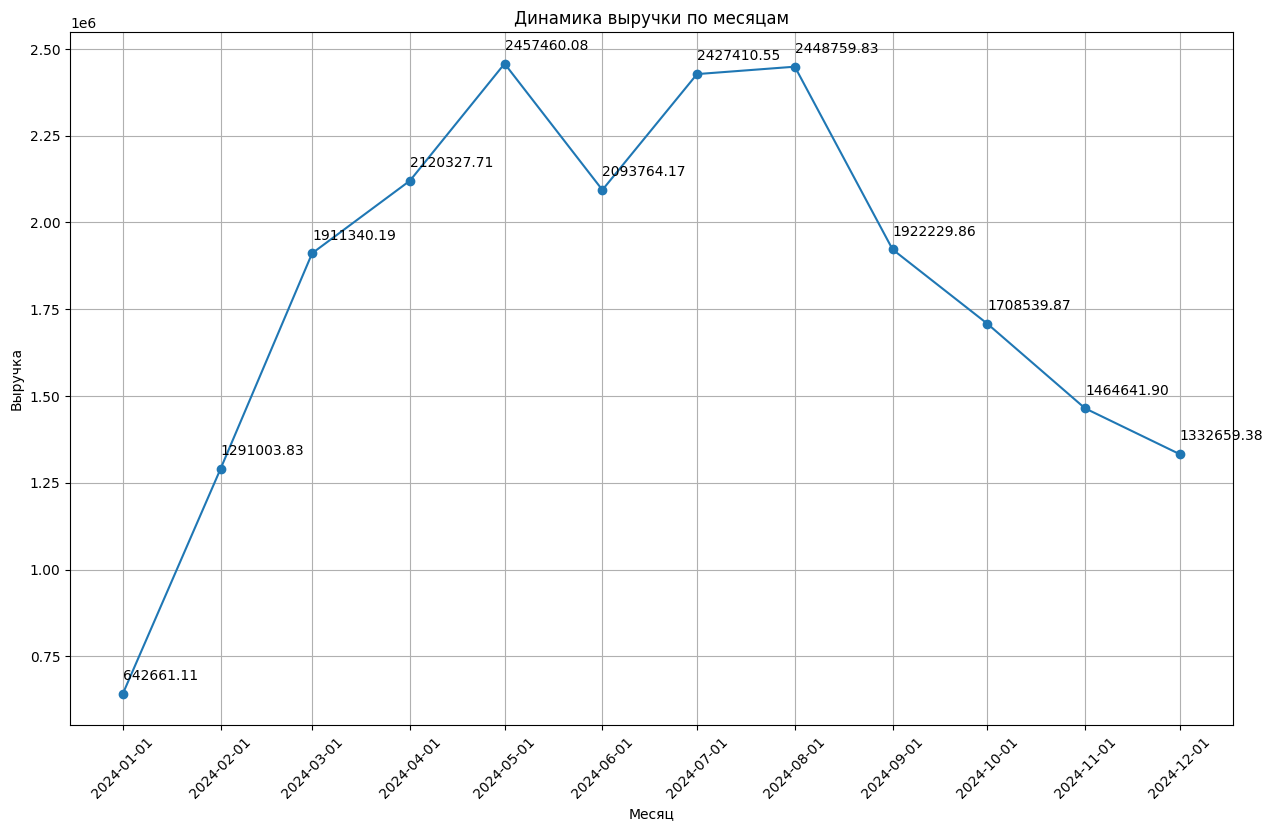

In [10]:
# Считаем метрику 
df_orders['revenue'] = df_orders['total_price'] * 0.05

# Готовим данные 
grouped = df_orders.groupby('order_month')['revenue'].sum().reset_index()

# Строим график 
plt.figure(figsize=(15,9))

plt.plot(grouped['order_month'], grouped['revenue'], marker='o')

# Настраиваем подписи
for x,y in zip(grouped['order_month'], grouped['revenue']):

    label = "{:.2f}".format(y)

    plt.annotate(label,
                 (x,y),
                 textcoords="offset points", 
                 xytext=(0,10),
                 ha='left')
    
plt.grid()
plt.title('Динамика выручки по месяцам')
plt.xlabel('Месяц')
plt.xticks(grouped['order_month'], rotation=45)
plt.ylabel('Выручка')
plt.show()

В первом полугодии наблюдается стремительный рост выручки — 648,890 рублей в январе до 2,478,758 рублей в мае. Однако пиковая точка в мае сменилась резким переломом тренда. Уже в июне происходит первое значительное падение выручки по сравнению с маем, после которого последовало частичное восстановление в июле и августе. Начиная с сентября наблюдается устойчивое и быстрое падение, продолжающееся до конца года.  
Пойдем по дереву метрик на уровень ниже, начнем с тех, что отражают интерес к маркетплэйсу.  
Посмотрим на DAU. Активным будем считать пользователя, который совершил какое-либо действие. 

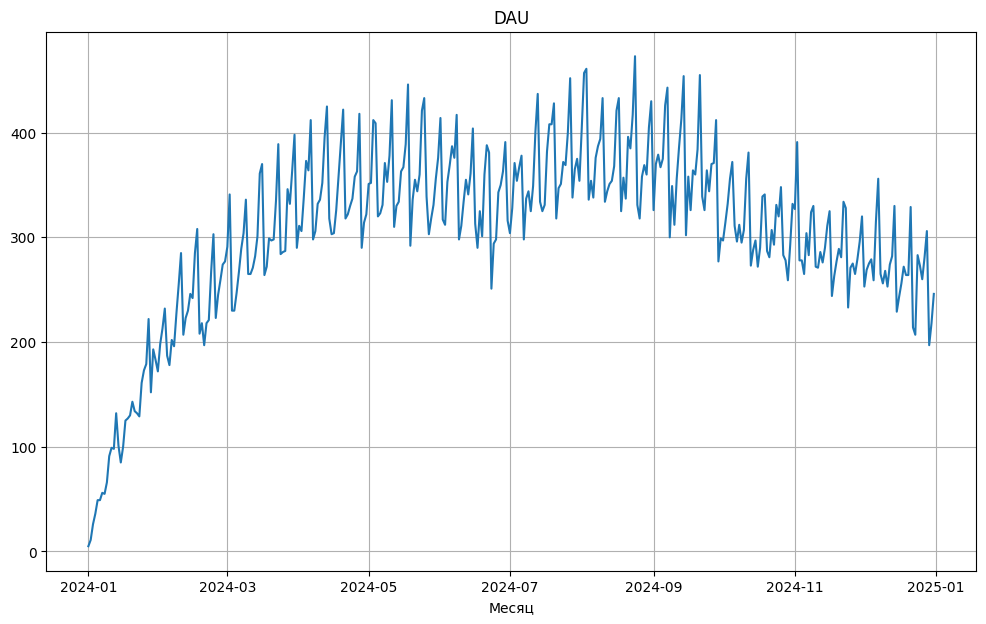

In [11]:
# Готовим данные 
dau = (df_events.groupby(df_events['event_date'].dt.date)['user_id']
       .nunique()
       .reset_index())

# Строим график 
plt.figure(figsize=(12,7))

plt.plot(dau['event_date'], dau['user_id'])

plt.title('DAU')
plt.xlabel('Месяц')
plt.grid()
plt.show()

Тренд повторяется: в начале года происходит интенсивное увеличение активной аудитории, которая стабилизируется к маю. В июне наблюдается спад. И уже к концу года пользоватлелей становится значительно меньше.  
Теперь посмотрим, насколько хорошо конвретируются в покупателей те, кто посещает площадку:

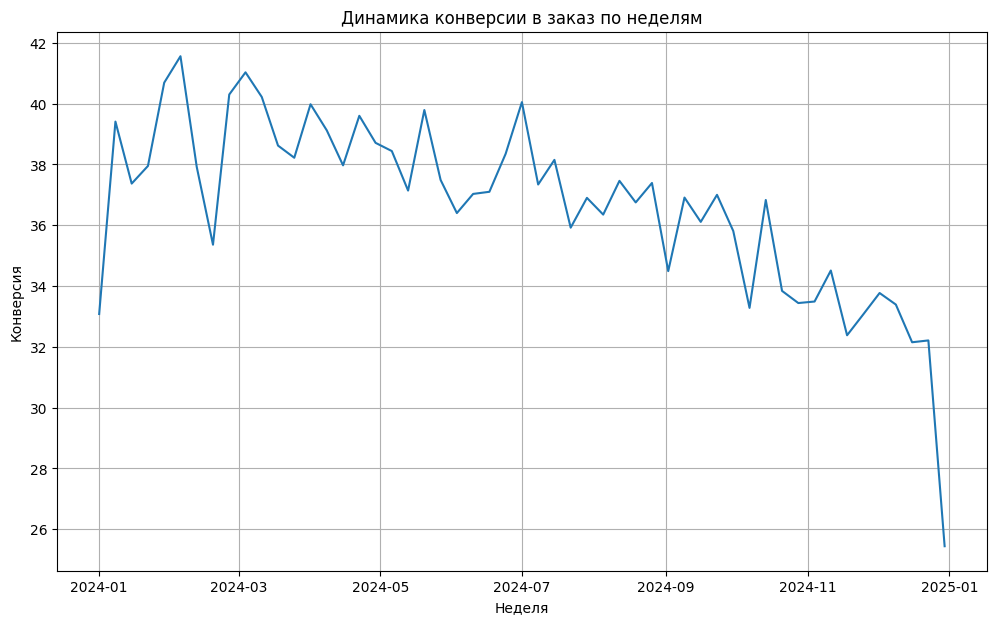

In [12]:
# Фильтруем по покупке 
buyers = df_events[df_events['event_type'] == 'checkout_complete'].copy()

# Группируем покупателей по неделям
buyers = (buyers.groupby('event_week')['user_id']
          .nunique()
          .reset_index()
          .rename(columns={'user_id': 'buyers_count'}))

# Группируем посетителей по неделям
users_count = (df_events.groupby('event_week')['user_id']
           .nunique()
           .reset_index()
           .rename(columns={'user_id': 'users_count'}))

conversion_to_purchase = users_count.merge(buyers, on='event_week', how='left')

conversion_to_purchase['CR'] = round(100 * conversion_to_purchase['buyers_count'] / conversion_to_purchase['users_count'], 2)

# Строим график 
plt.figure(figsize=(12,7))

plt.plot(conversion_to_purchase['event_week'], conversion_to_purchase['CR'])

plt.title('Динамика конверсии в заказ по неделям')
plt.xlabel('Неделя')
plt.ylabel('Конверсия')
plt.grid()
plt.show()

График показывает стабильно высокую конверсию в первом полугодии (38-42%) и устойчивым спадом во втором. Критическое падение произошло в декабре — конверсия упала до 25%, что стало минимумом за год.  
Метрики демонстрируют тревожный сигнал: платформа все хуже удерживает пользователей и конвертирует их в покупателей.  
Проанализируем AOV, чтобы увидеть, как данная ситуация сказалась на монетизации:

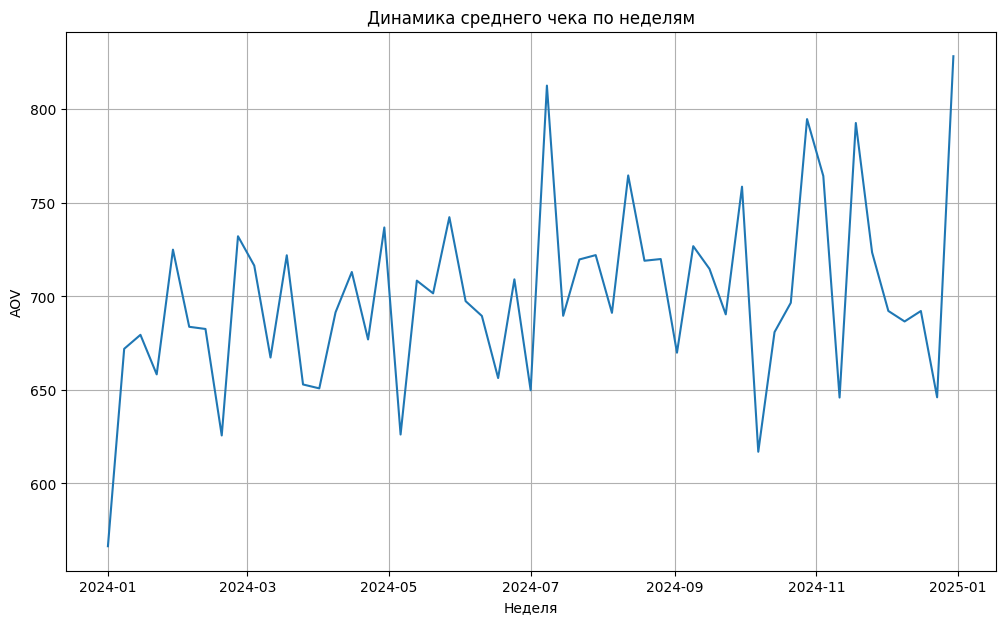

In [13]:
# Группируем данные по неделям
aov = (df_orders.groupby('order_week')
       .agg(revenue=('revenue', 'sum'),
            orders_count=('order_id', 'nunique'))
       .reset_index())

# Считаем средний чек
aov['aov'] = round(aov['revenue'] / aov['orders_count'], 2)

# Строим график 
plt.figure(figsize=(12,7))

plt.plot(aov['order_week'], aov['aov'])
plt.title('Динамика среднего чека по неделям')
plt.xlabel('Неделя')
plt.ylabel('AOV')
plt.grid()
plt.show()

Значения преимущественно колеблются в диапазоне от 650 до 750 рублей, демонстрируя стабильность среднего чека.  
Обзор верхнеуровневых метрик позволяет сделать важный вывод: несмотря на сокращение количества пользователей и ухудшение конверсии, платформа сохранила способность монетизировать оставшихся — они не стали тратить значительно меньше. Следовательно, основная проблема не в ценовой политике, а в привлечении и удержании аудитории.

## Оценка метрик монетизации и юнит-экономики

Посмотрим эффективность маркетинга и возврат инвестиций в привлечение клиента.

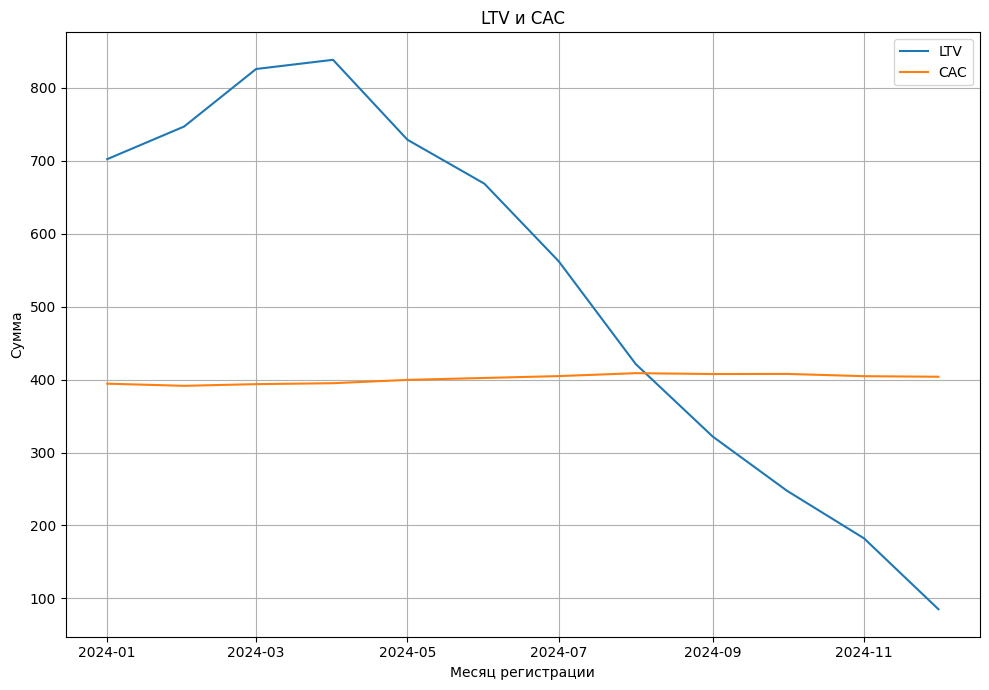

In [14]:
# Объединяем данные
df_merged = df_orders.merge(df_users[['user_id', 'cohort_month']], on='user_id')

# Считаем общий доход по каждой когорте
cohort_revenue = df_merged.groupby('cohort_month')['revenue'].sum().reset_index()

# Считаем размер каждой когорты
cohort_sizes = (df_users.groupby('cohort_month')['user_id']
                .nunique()
                .reset_index()
                .rename(columns={'user_id': 'cohort_size'}))

# Объединяем доход с размерами когорт
cohort_analysis = pd.merge(cohort_revenue, cohort_sizes, on='cohort_month')

# Рассчитываем LTV (общий доход на пользователя за все время)
cohort_analysis['LTV'] = cohort_analysis['revenue'] / cohort_analysis['cohort_size']

# Суммируем общий бюджет по месяцам
total_budget = (df_campaign_costs.groupby('spend_month')['budget']
                .sum()
                .reset_index()
                .rename(columns={'spend_month': 'cohort_month',
                                'budget': 'total_budget'}))

# Считаем количество привлеченных пользователей по месяцам
users_acquired = (df_users.groupby('cohort_month')['user_id']
                  .nunique()
                  .reset_index()
                  .rename(columns={'user_id': 'users_acquired'}))

# Объединяем и рассчитываем CAC
cac_analysis = pd.merge(total_budget, users_acquired, on='cohort_month')
cac_analysis['CAC'] = cac_analysis['total_budget'] / cac_analysis['users_acquired']

# Объединяем LTV и CAC
ltv_cac = pd.merge(cohort_analysis, cac_analysis[['cohort_month', 'CAC']], on='cohort_month', how='left')


# Стороим график
plt.figure(figsize=(10, 7))

plt.plot(ltv_cac['cohort_month'], ltv_cac['LTV'], label='LTV')
plt.plot(ltv_cac['cohort_month'], ltv_cac['CAC'], label='CAC')

plt.title('LTV и CAC')
plt.xlabel('Месяц регистрации')
plt.ylabel('Сумма')
plt.grid()
plt.legend()
plt.tight_layout()

plt.show()

Динамика LTV подтвержает негативный тренд удержания: рост в первом полугодии был обеспечен высокой конверсией и увеличением активной аудитории. Тогда как во втором полугодии спад метрик вовлеченности привел к резкому снижению LTV, при почти неизменном CAC, что ставит под сомнение эффективность маркетинговых затрат. Рассчитаем и визуализируем ROI, чтобы количественно оценить, насколько снижение LTV и удержания снизило отдачу от вложений в привлечение пользователей:

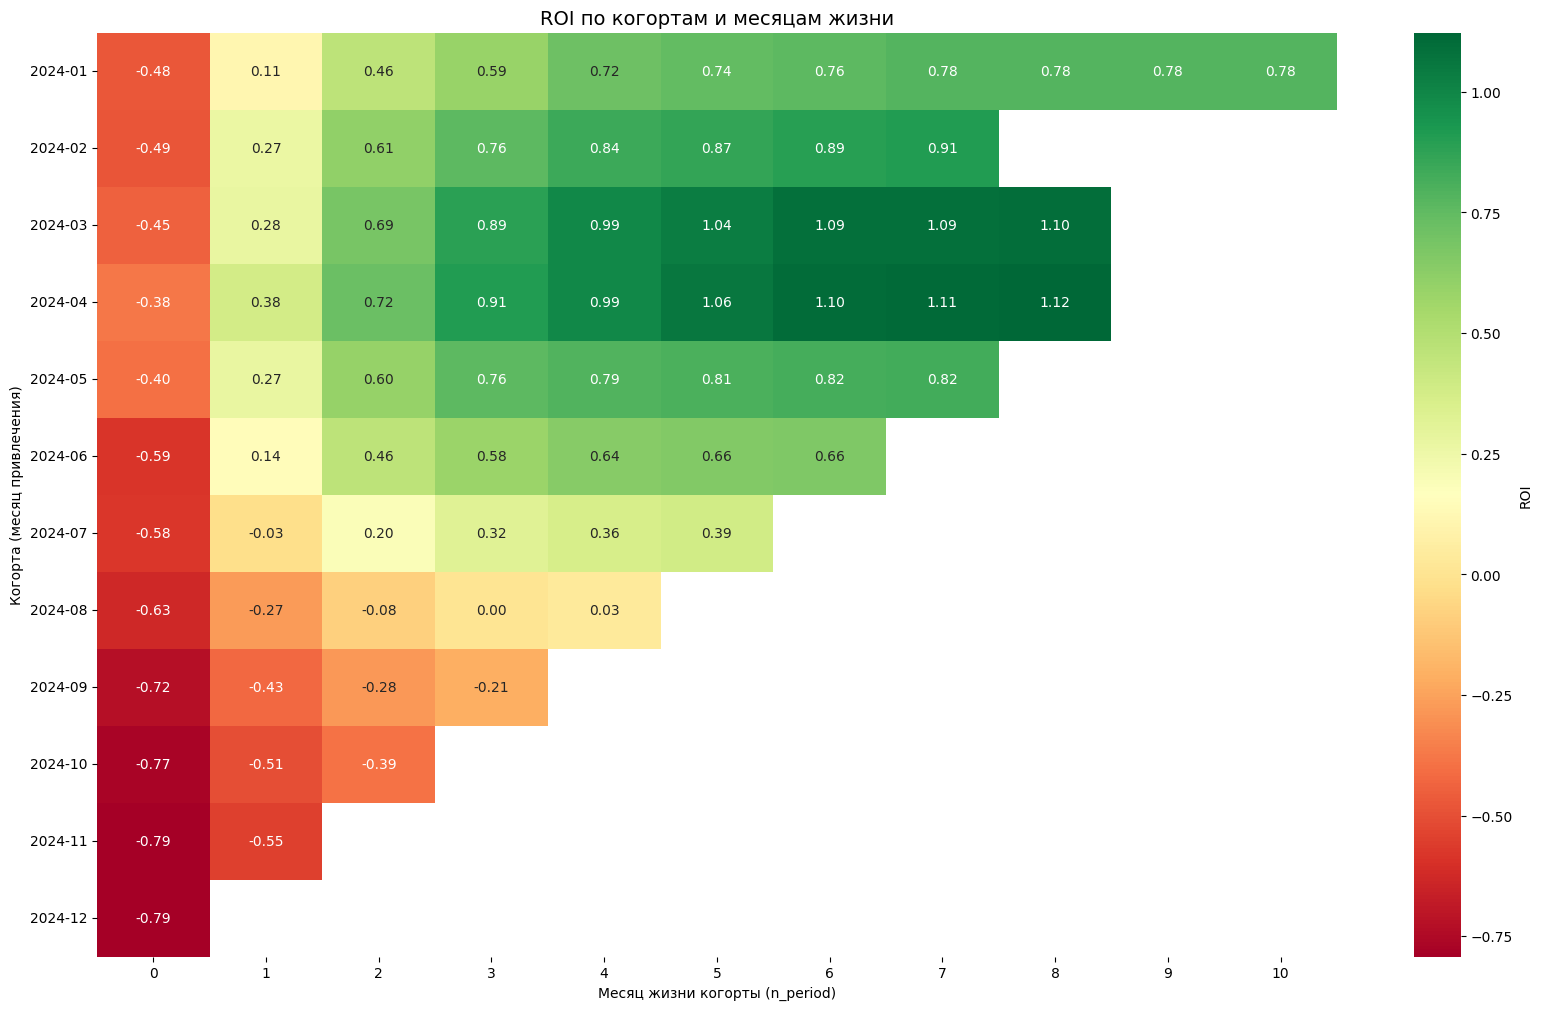

In [15]:
# Считаем месяц активности
df_merged['n_period'] = (df_merged['order_month'].dt.to_period('M') - 
                        df_merged['cohort_month'].dt.to_period('M')).apply(lambda x: x.n)

# Суммируем общую выручку по когортам и периодам
df_period = (df_merged.groupby(['cohort_month', 'n_period'])['revenue']
             .sum()
             .reset_index())

# Считаем количество уникальных пользователей в каждой когорте
users_period = (df_users.groupby('cohort_month')['user_id']
                .nunique()
                .reset_index()
                .rename(columns={'user_id': 'cohort_size'}))

# Объединяем выручку с размером когорты
ltv_period = pd.merge(df_period, users_period, on='cohort_month')

# Рассчитываем кумулятивную выручку
ltv_period['cumulative_revenue'] = ltv_period.groupby('cohort_month')['revenue'].cumsum()

# Рассчитываем кумулятивный LTV 
ltv_period['LTV'] = ltv_period['cumulative_revenue'] / ltv_period['cohort_size']

# Суммируем бюджет по месяцу привлечения
costs = (df_campaign_costs.groupby('spend_month')['budget']
       .sum()
       .reset_index()
       .rename(columns={'spend_month': 'cohort_month'}))

# Готовим данные для расчета CAC
cac_period = costs.merge(users_period, on='cohort_month')

# Считаем CAC
cac_period['CAC'] = cac_period['budget'] / cac_period['cohort_size']

# Объединяем с основным датафреймом
ltv_period = pd.merge(ltv_period, cac_period[['cohort_month', 'CAC']], on='cohort_month')

# Считаем ROI
ltv_period['ROI'] = (ltv_period['LTV'] - ltv_period['CAC']) / ltv_period['CAC']

# Преобразуем cohort_month в формат YYYY-MM
ltv_period['cohort_month_str'] = ltv_period['cohort_month'].dt.strftime('%Y-%m')

# Строим матрицу ROI 
roi_matrix = ltv_period.pivot_table(
    index='cohort_month_str',
    columns='n_period',
    values='ROI',
    aggfunc='first')

# Строим график
plt.figure(figsize=(20,12))

sns.heatmap(
    roi_matrix, 
    cmap='RdYlGn', 
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'ROI'}
)

plt.title('ROI по когортам и месяцам жизни', fontsize=14)
plt.xlabel('Месяц жизни когорты (n_period)')
plt.yticks(rotation=0)
plt.ylabel('Когорта (месяц привлечения)')
plt.show()

ROI показывает чёткую зависимость от удержания и конверсии: первые когорты года постепенно выходят в положительную отдачу и достигают 0.78–0.80, но с июня по декабрь ROI остаётся низким или отрицательным за те же периоды. Это отражает падение LTV из-за снижения активности и конверсии пользователей, что резко уменьшает эффективность маркетинговых вложений.

## Выводы по этапам 2 и 3

Проведенный анализ показывает падение выручки во втором полугодии из-за снижения удержания и конверсии в заказ. При этом средний чек остаётся стабильным, что подтверждает отсутствие проблем с монетизацией уже привлечённых пользователей. Неизменный CAC усугубляет ситуацию за счёт падающего LTV, что снижает ROI поздних когорт и делает маркетинговые вложения менее эффективными. Это напрямую указывает на проблему в источниках привлечения: ключевым становится детальный анализ LTV, CAC и ROI по каналам, чтобы понять, какие каналы работают стабильно, а какие приводят к неэффективным затратам, и перераспределить бюджет в пользу устойчивых источников.

## Поиск инсайтов, точек роста и сегментация


Посмторим детальнее на LTV, CAC и ROI по каналам:

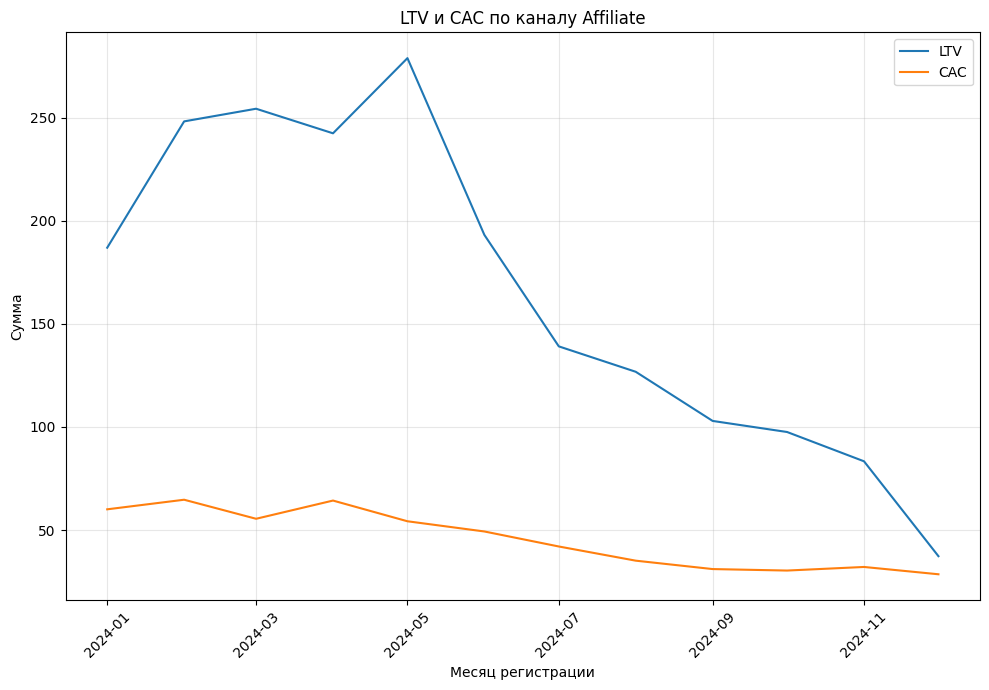

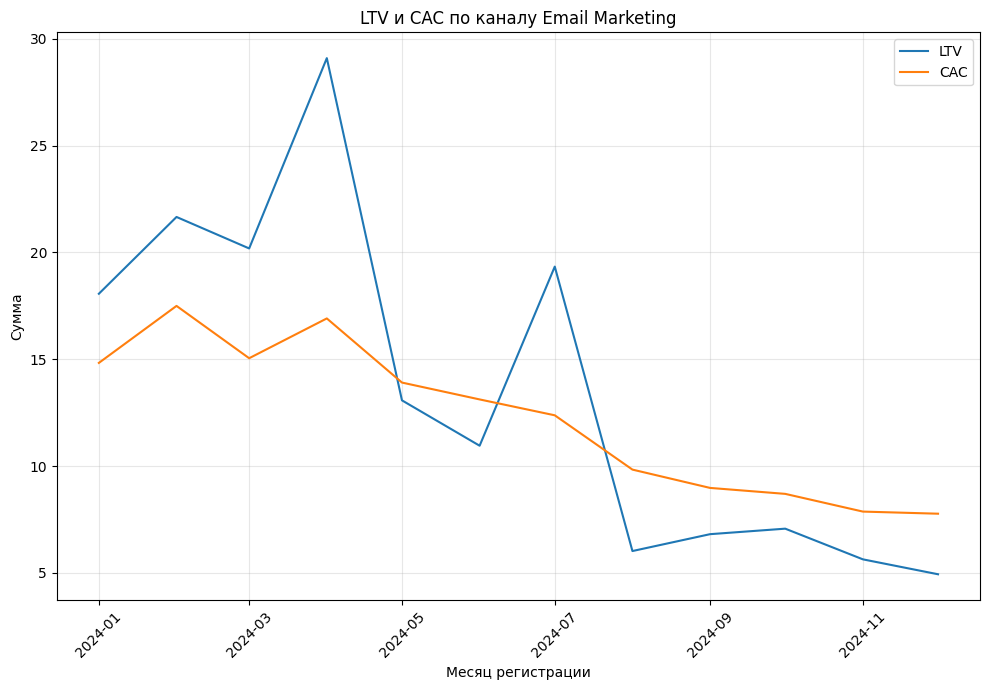

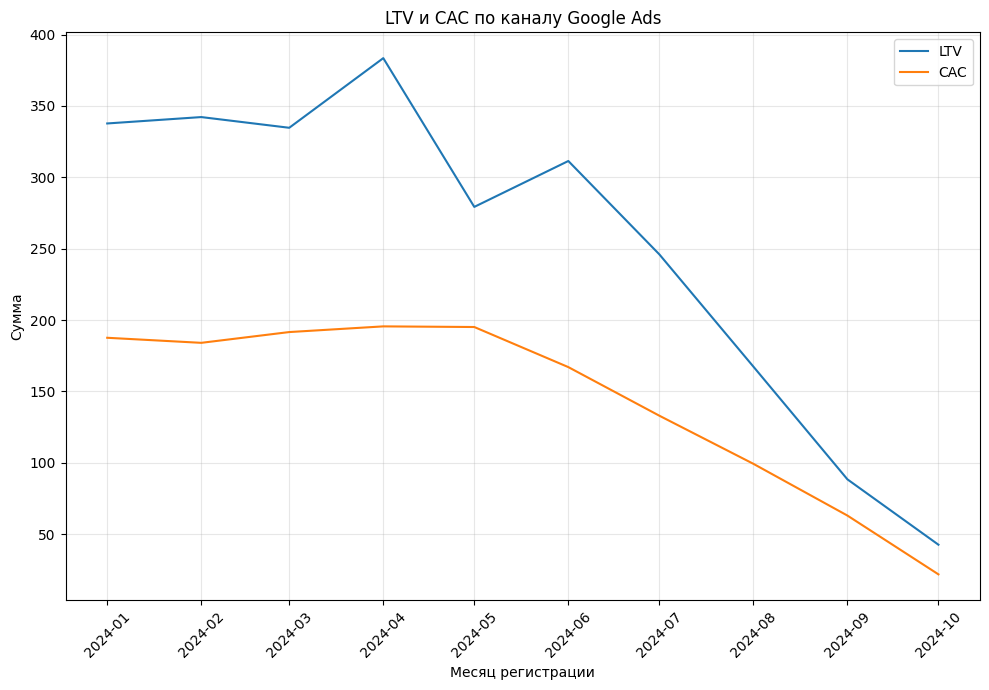

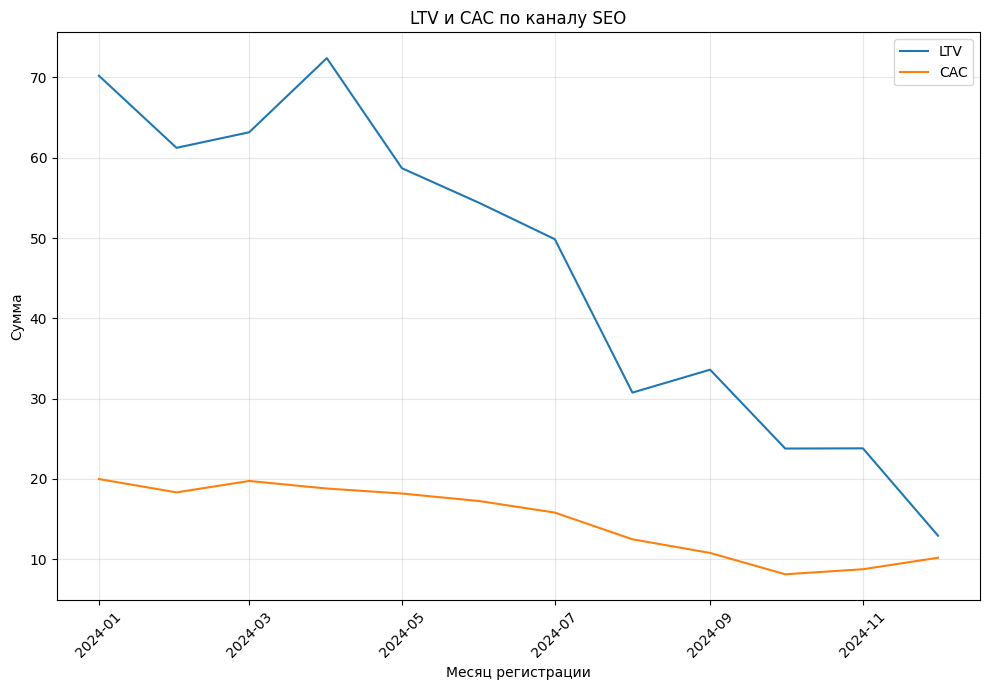

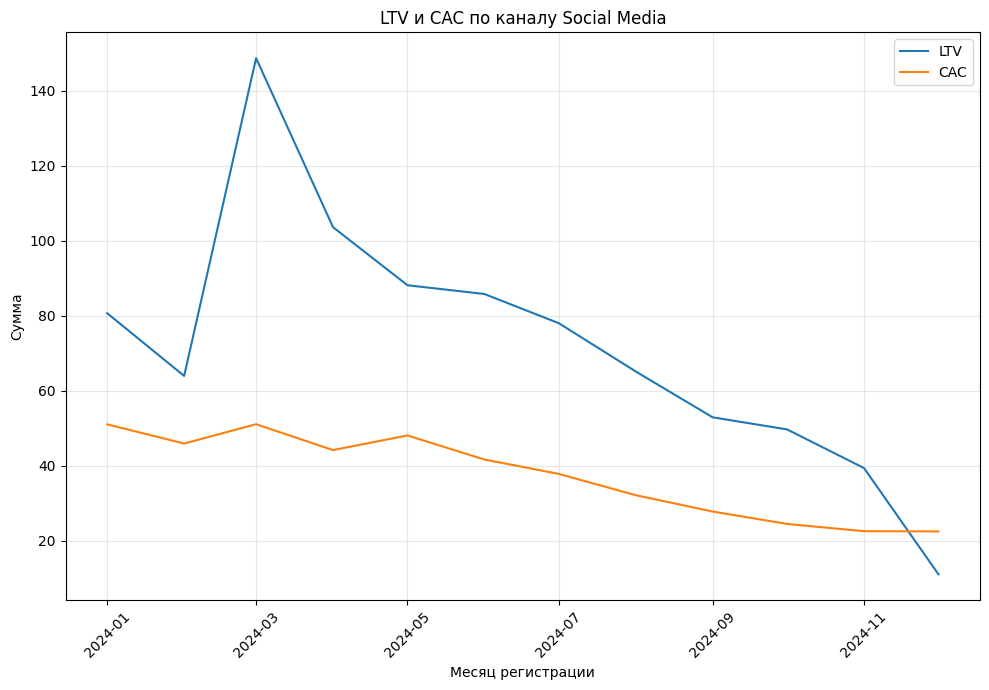

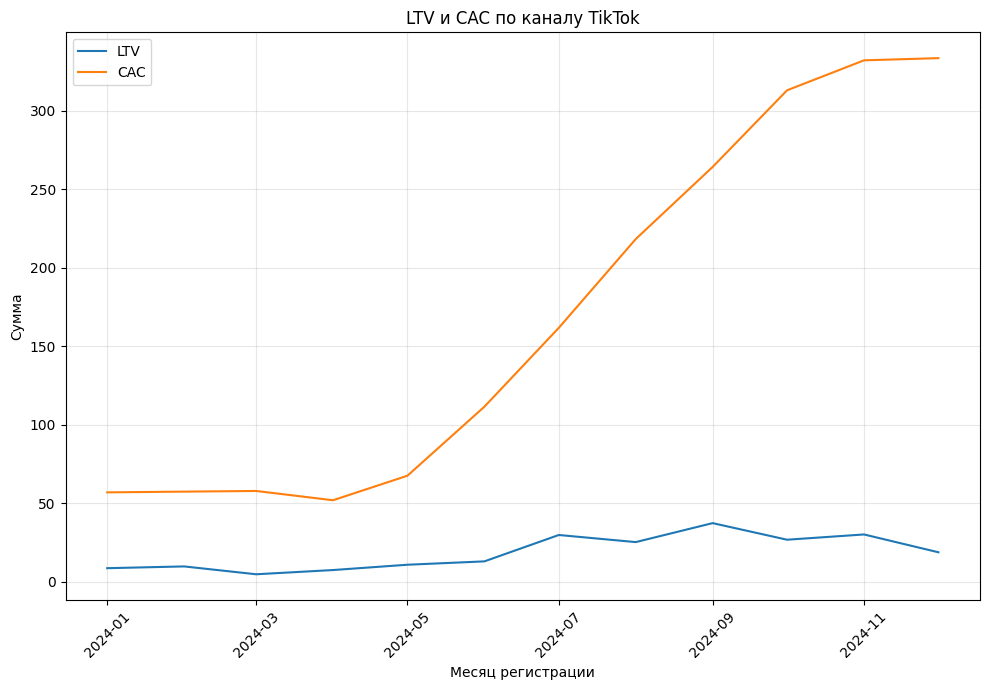

In [16]:
# Объединяем данные
df_merged = df_orders.merge(df_users[['user_id', 'cohort_month', 'acq_channel']], on='user_id')

# Считаем общий доход по каждой когорте
cohort_revenue = df_merged.groupby(['cohort_month', 'acq_channel'])['revenue'].sum().reset_index()

# Считаем размер каждой когорты
cohort_sizes = (df_users.groupby('cohort_month')['user_id']
                .nunique()
                .reset_index()
                .rename(columns={'user_id': 'cohort_size'}))

# Объединяем доход с размерами когорт
cohort_analysis = pd.merge(cohort_revenue, cohort_sizes, on='cohort_month')

# Рассчитываем LTV (общий доход на пользователя за все время)
cohort_analysis['LTV'] = cohort_analysis['revenue'] / cohort_analysis['cohort_size']

# Суммируем общий бюджет по месяцам
total_budget = (df_campaign_costs.groupby(['spend_month', 'acq_channel'])['budget']
                .sum()
                .reset_index()
                .rename(columns={'spend_month': 'cohort_month',
                                'budget': 'total_budget'}))

# Считаем количество привлеченных пользователей по месяцам
users_acquired = (df_users.groupby('cohort_month')['user_id']
                  .nunique()
                  .reset_index()
                  .rename(columns={'user_id': 'users_acquired'}))

# Объединяем и рассчитываем CAC
cac_analysis = pd.merge(total_budget, users_acquired, on='cohort_month')
cac_analysis['CAC'] = cac_analysis['total_budget'] / cac_analysis['users_acquired']

# Объединяем LTV и CAC
ltv_cac = pd.merge(cohort_analysis, 
                   cac_analysis[['cohort_month', 'CAC', 'acq_channel']],
                   on=['cohort_month', 'acq_channel'],
                   how='left')

for channel in ltv_cac['acq_channel'].unique():
    # Фильтруем по каналу
    filtered = ltv_cac[ltv_cac['acq_channel'] == channel]
    
    # Строим график
    plt.figure(figsize=(10, 7))
    
    plt.plot(filtered['cohort_month'], filtered['LTV'], label='LTV')
    plt.plot(filtered['cohort_month'], filtered['CAC'], label='CAC')

    plt.title(f'LTV и CAC по каналу {channel}')
    plt.xlabel('Месяц регистрации')
    plt.ylabel('Сумма')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

`Google Ads` демонстрирует изначально высокую рентабельность в начале периода с существенным превышением LTV над CAC. Однако в последующих месяцах отмечается значительное сокращение разрыва, указывающее на снижение эффективности инвестиций.`Affiliate` и `Social Media` характеризуются относительным балансом показателей на протяжении всего периода. Каналы `SEO` и `Email Marketing` показывают минимальную разницу между метриками, что свидетельствует об их низкой абсолютной эффективности.  
Наиболее проблемный сегмент представляет канал `TikTok`, где CAC стремительно растет при неизменном LTV. Данная динамика делает канал убыточным и уменьшает общую эффективность.  
Проанализируем долю `TikTok` в общем объёме привлечённых пользователей:

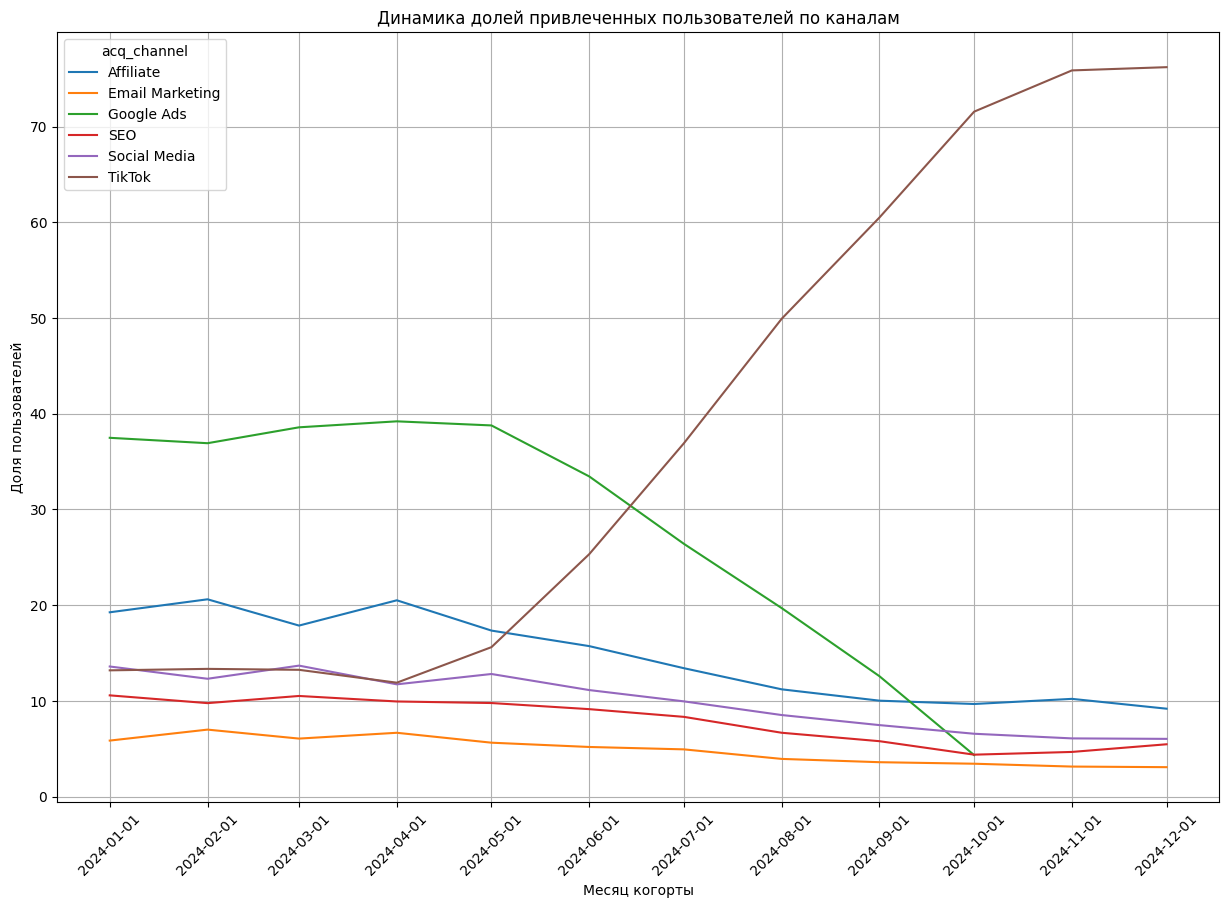

In [17]:
# Считаем пользователей по кналам
user_channel_counts = (df_users.groupby(['cohort_month', 'acq_channel'])['user_id']
                      .nunique()
                      .reset_index()
                      .rename(columns={'user_id': 'channel_counts'}))

# Считаем количетсво пользователей по месяцам
user_counts = (df_users.groupby('cohort_month')['user_id']
                      .nunique()
                      .reset_index()
                      .rename(columns={'user_id': 'user_counts'}))

# Создаем таблицу для расчета доли
channel_share = pd.merge(user_channel_counts, user_counts, on='cohort_month')

# Считаем долю
channel_share['channel_share'] =  100 * channel_share['channel_counts'] / channel_share['user_counts']

# Строим график
plt.figure(figsize=(15,10))

sns.lineplot(data=channel_share,
            x='cohort_month',
            y='channel_share',
            hue='acq_channel')

plt.grid()
plt.xticks(rotation=45, ticks=channel_share['cohort_month'].unique())
plt.title('Динамика долей привлеченных пользователей по каналам')
plt.ylabel('Доля пользователей')
plt.xlabel('Месяц когорты')
plt.show()

Доля `TikTok` выросла с 13% в январе до 75% в декабре, что объясняет падение общей рентабельности. При стремительно растущих вложениях маркетплэйс получает трафик с плохой платежеспособностью. Это напрямую отражается на показателе ROI:

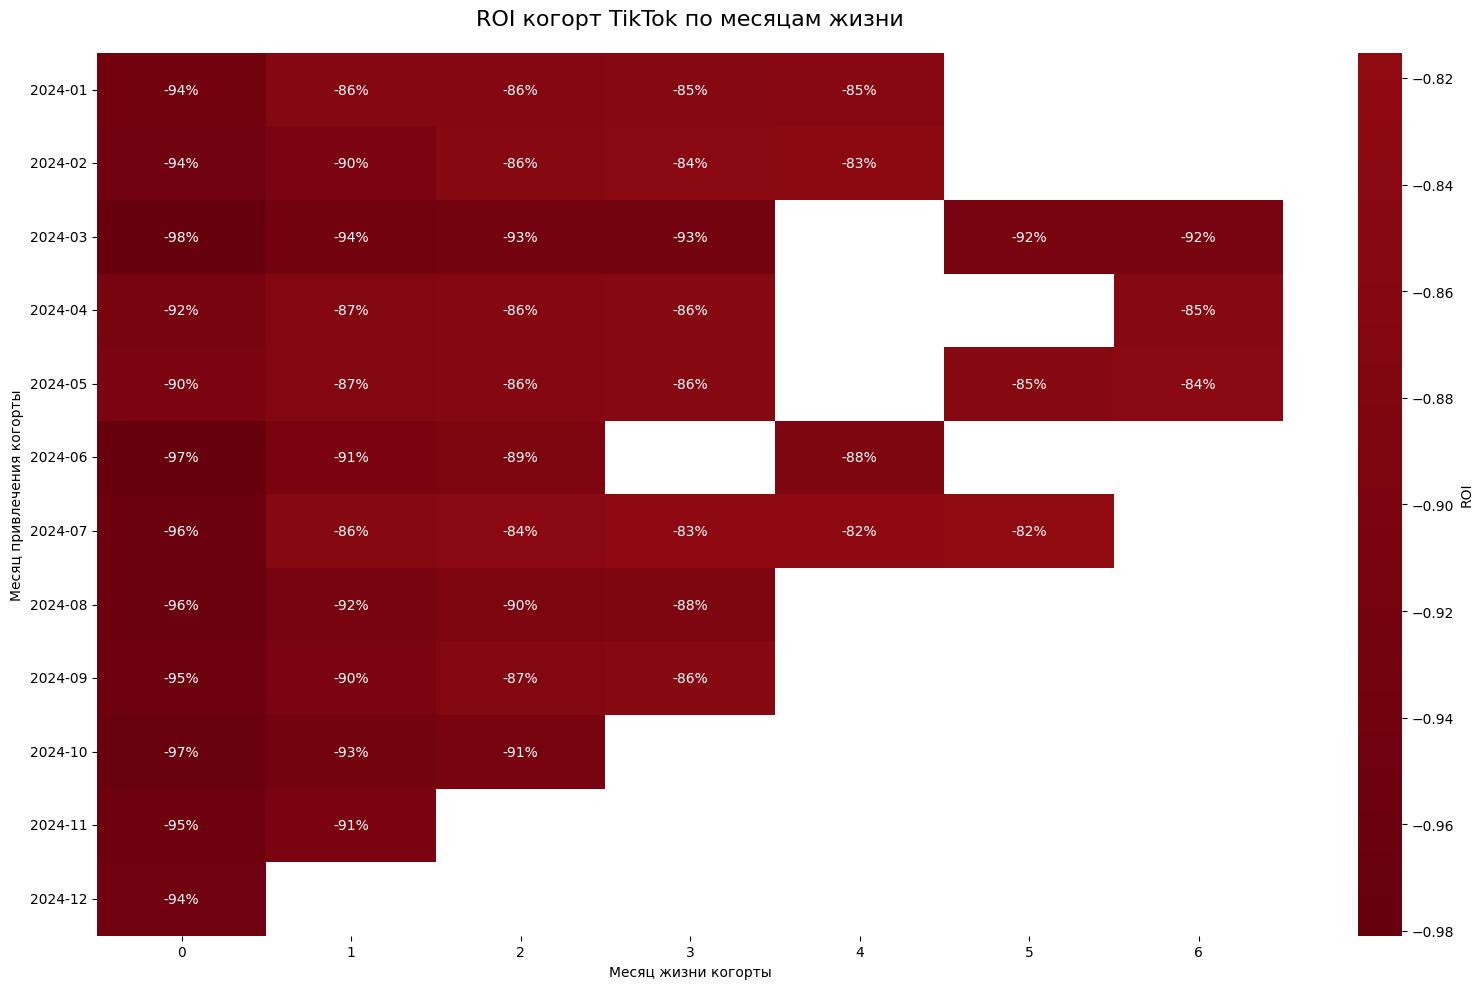

In [18]:
# Фильтруем данные только по TikTok
df_users_tiktok = df_users[df_users['acq_channel'] == 'TikTok']
df_campaign_tiktok = df_campaign_costs[df_campaign_costs['acq_channel'] == 'TikTok']

# Объединяем заказы только с пользователями TikTok
df_merged_tiktok = df_orders.merge(df_users_tiktok[['user_id', 'cohort_month']], on='user_id')

# Считаем месяц активности для TikTok
df_merged_tiktok['n_period'] = (df_merged_tiktok['order_month'].dt.to_period('M') - 
                               df_merged_tiktok['cohort_month'].dt.to_period('M')).apply(lambda x: x.n)

# Суммируем общую выручку по когортам и периодам для TikTok
df_period_tiktok = (df_merged_tiktok.groupby(['cohort_month', 'n_period'])['revenue']
                   .sum()
                   .reset_index())

# Считаем количество уникальных пользователей TikTok в каждой когорте
users_period_tiktok = (df_users_tiktok.groupby('cohort_month')['user_id']
                      .nunique()
                      .reset_index()
                      .rename(columns={'user_id': 'cohort_size'}))

# Объединяем выручку с размером когорты для TikTok
ltv_period_tiktok = pd.merge(df_period_tiktok, users_period_tiktok, on='cohort_month')

# Рассчитываем кумулятивную выручку для TikTok
ltv_period_tiktok['cumulative_revenue'] = ltv_period_tiktok.groupby('cohort_month')['revenue'].cumsum()

# Рассчитываем кумулятивный LTV для TikTok
ltv_period_tiktok['LTV'] = ltv_period_tiktok['cumulative_revenue'] / ltv_period_tiktok['cohort_size']

# Суммируем бюджет TikTok по месяцу привлечения
costs_tiktok = (df_campaign_tiktok.groupby('spend_month')['budget']
               .sum()
               .reset_index()
               .rename(columns={'spend_month': 'cohort_month'}))

# Готовим данные для расчета CAC TikTok
cac_period_tiktok = costs_tiktok.merge(users_period_tiktok, on='cohort_month')

# Считаем CAC для TikTok
cac_period_tiktok['CAC'] = cac_period_tiktok['budget'] / cac_period_tiktok['cohort_size']

# Объединяем с основным датафреймом для TikTok
ltv_period_tiktok = pd.merge(ltv_period_tiktok, cac_period_tiktok[['cohort_month', 'CAC']], on='cohort_month')

# Считаем ROI для TikTok
ltv_period_tiktok['ROI'] = (ltv_period_tiktok['LTV'] - ltv_period_tiktok['CAC']) / ltv_period_tiktok['CAC']

# Преобразуем cohort_month в формат YYYY-MM
ltv_period_tiktok['cohort_month_str'] = ltv_period_tiktok['cohort_month'].dt.strftime('%Y-%m')

# Строим матрицу ROI только для TikTok
roi_matrix_tiktok = ltv_period_tiktok.pivot_table(
    index='cohort_month_str',
    columns='n_period',
    values='ROI',
    aggfunc='first')

# Строим график
plt.figure(figsize=(16, 10))

sns.heatmap(
    roi_matrix_tiktok, 
    cmap='Reds_r',
    annot=True,
    fmt='.0%',
    center=0,
    cbar_kws={'label': 'ROI'}
)

plt.title('ROI когорт TikTok по месяцам жизни', fontsize=16, pad=20)
plt.xlabel('Месяц жизни когорты')
plt.ylabel('Месяц привлечения когорты')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

К концу года каждый вложенный рубль приносит убыток в размере примерно 94 копеек при отрицательной динамике на протяжении всего наблюдаемого периода. Требуется сократить вложения в `TikTok` и перенаправить бюджет в рентабельные каналы.  
Проанализируем метрики удержания по каналам, чтобы виделить перспективные направления для финансирования. Начнем с метрики stickiness, так как она хорошо отражает привычку и вовлеченность пользователя:

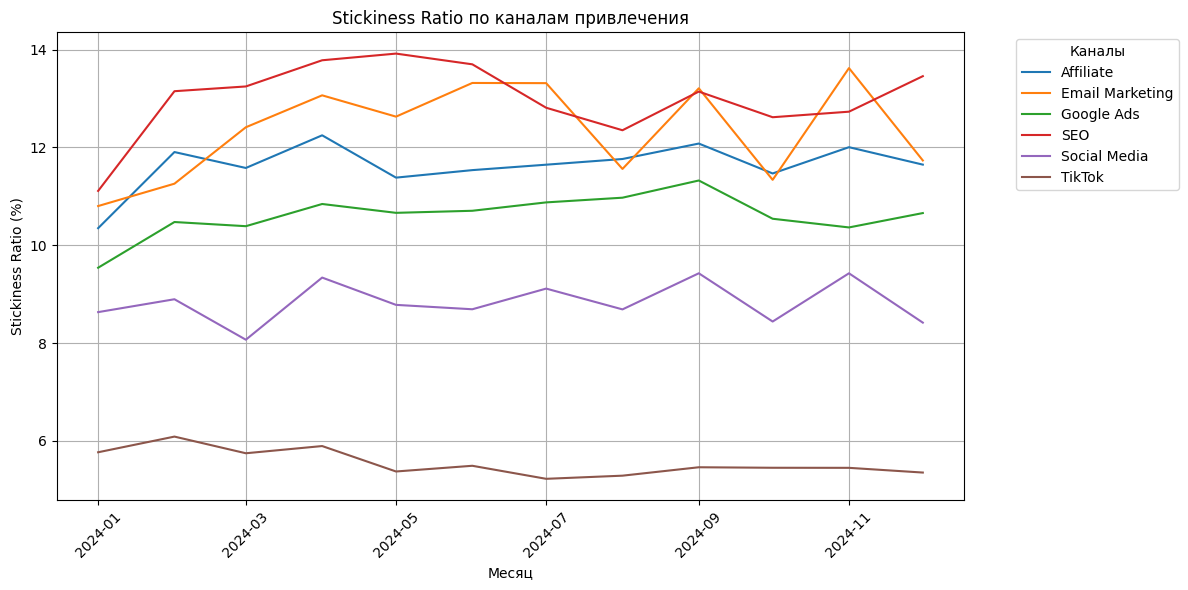

In [19]:
# Объединим данные и рассчитаем MAU
df_events_with_channel = pd.merge(df_events, df_users[['user_id', 'acq_channel']], on='user_id', how='left')

# Cчитаем MAU
mau = (df_events_with_channel.groupby(['event_month', 'acq_channel'])['user_id']
       .nunique()
       .reset_index()
       .rename(columns={'user_id': 'mau'}))

# Считаем среднемесячный DAU
dau_daily = (df_events_with_channel.groupby([df_events_with_channel['event_date'].dt.date, 'acq_channel'])['user_id']
            .nunique()
            .reset_index()
            .rename(columns={'event_date': 'date', 'user_id': 'dau'}))

dau_daily['date'] = pd.to_datetime(dau_daily['date'])

dau_daily['event_month'] = dau_daily['date'].dt.to_period('M').dt.to_timestamp()

# Считаем среднемесячный DAU
dau_monthly_avg = (dau_daily.groupby(['event_month', 'acq_channel'])['dau']
                   .mean()
                   .reset_index()
                   .rename(columns={'dau': 'dau_monthly'}))

# Объединяем MAU и среднемесячный DAU
stickiness_table = pd.merge(mau, dau_monthly_avg, on=['event_month', 'acq_channel'], how='left')

# Рассчитаем Stickiness ratio
stickiness_table['stick'] = 100 * (stickiness_table['dau_monthly'] / stickiness_table['mau'])

# Строим график
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=stickiness_table,
    x='event_month',
    y='stick',
    hue='acq_channel')

plt.title('Stickiness Ratio по каналам привлечения')
plt.xlabel('Месяц')
plt.ylabel('Stickiness Ratio (%)')
plt.grid()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Каналы')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

`SEO` имеет самую лучшую активную аудиторию, которая возвращается в продукт ежедневно. `Email Marketing` близок к тем же значениям.  
Аудитория `Affiliate` и `Google Ads` приходит, но не проявляет высокой лояльности. `Social Media` заметно отстает, что наводит на мысль о более пассивном поведении пользователей.  
Наиболее тревожная ситуация с `TikTok` — показатель stickiness примерно вполовину ниже среднего. Канал привлекает массовый трафик, но совершенно не способен его удержать.  
Но лояльность имеет ценность, если она приводит к покупкам. Посмотрим, насколько хорошо пользователи с разных каналов ковертируются в заказ:

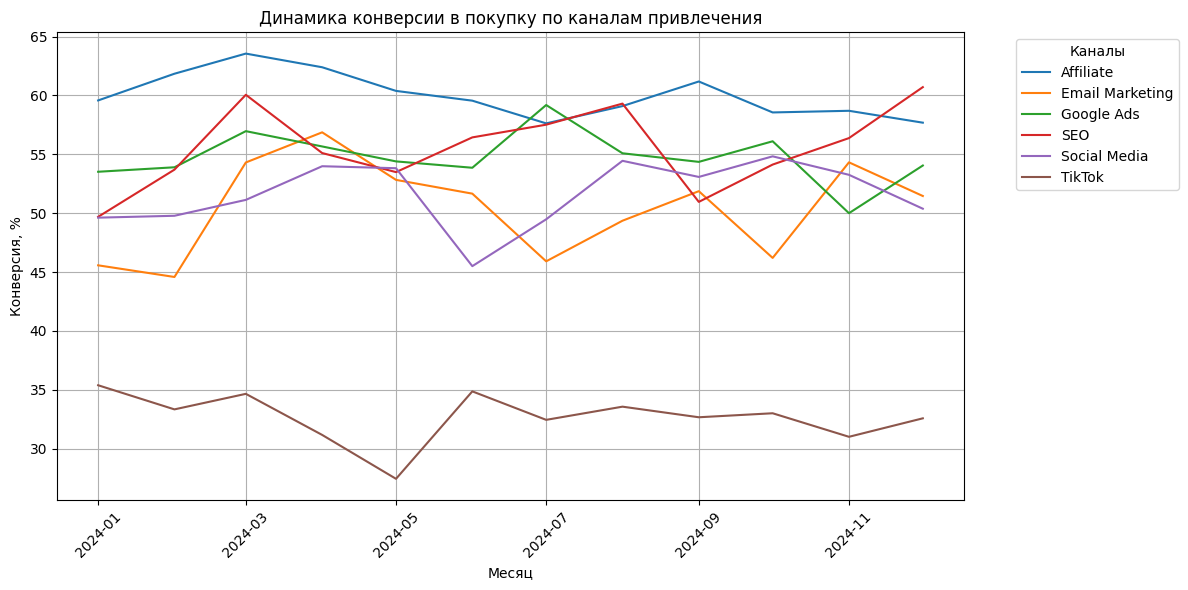

In [20]:
# Фильтруем по покупке и добавляем канал привлечения
buyers = (df_events[df_events['event_type'] == 'checkout_complete']
          .merge(df_users[['user_id', 'acq_channel']], on='user_id', how='left')
          .copy())

# Группируем покупателей по месяцам и каналам
buyers_monthly = (buyers.groupby(['event_month', 'acq_channel'])['user_id']
                  .nunique()
                  .reset_index()
                  .rename(columns={'user_id': 'buyers_count'}))

# Группируем всех пользователей по месяцам и каналам
users_monthly = (df_events.merge(df_users[['user_id', 'acq_channel']], on='user_id', how='left')
                  .groupby(['event_month', 'acq_channel'])['user_id']
                  .nunique()
                  .reset_index()
                  .rename(columns={'user_id': 'users_count'}))

# Объединяем и считаем конверсию
conversion_by_channel = users_monthly.merge(buyers_monthly, on=['event_month', 'acq_channel'], how='left')
conversion_by_channel['CR'] = round(100 * conversion_by_channel['buyers_count'] / conversion_by_channel['users_count'], 2)

# Строим график
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=conversion_by_channel,
    x='event_month',
    y='CR',
    hue='acq_channel')

plt.title('Динамика конверсии в покупку по каналам привлечения')
plt.xlabel('Месяц')
plt.ylabel('Конверсия, %')
plt.grid()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Каналы')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

`Affiliate` стабильно показывает высокую конверсию на уровне 58-63% на протяжении всего года, пложительно показывая качество трафика. `Google Ads` также имеет хорошие результаты в диапазоне 53-59%.  
`SEO` и `Email Marketing` проявляют себя как эффективные каналы , причем `SEO` демонстрирует особенно внушительные результаты в начале и конце года. `Social Media` нестабилен, что может говорить о зависимости от конкретных кампаний или контента.  

Таким образом, приоритетными каналами для финансирования являются `SEO` и `Affiliate` благодаря высокой лояльности и конверсии. `Google Ads` и `Email Marketing` показывают стабильную эффективность и требуют поддерживающего бюджета. `TikTok` необходимо полностью закрыть из-за убыточности (низкие Stickiness 5–6% и конверсия 27–35% при высоких затратах). `Social Media` нестабильна.  
Прейдем к поведенческому анализу пользователей. Начнем с воронки конверсий, чтобы выявить слабые места:

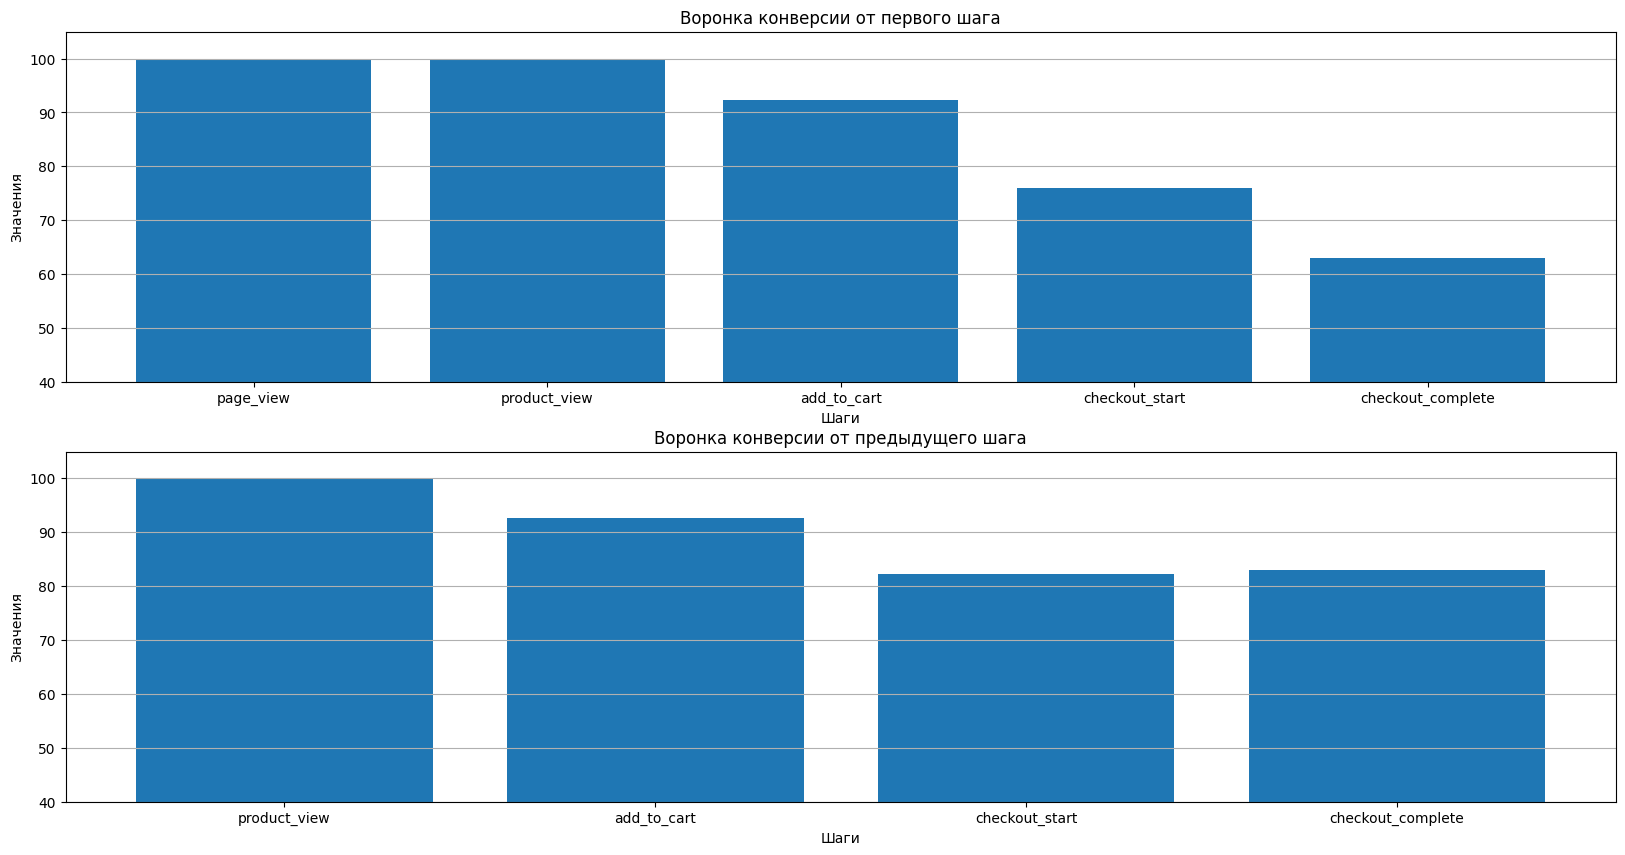

In [21]:
# Выделяем ключевые шаги
funnel_steps = [
    'page_view',
    'product_view', 
    'add_to_cart',
    'checkout_start',
    'checkout_complete'
]

# Фильтруем только нужные шаги и считаем пользователей
funnel_df = df_events[df_events['event_type'].isin(funnel_steps)]
funnel_df = (funnel_df.groupby('event_type')['user_id']
             .nunique()
             .reindex(funnel_steps)
             .reset_index()
             .rename(columns={'user_id': 'users_n'}))

# Считаем конверсию от первого шага
funnel_df['conversion_from_first_step_%'] = funnel_df['users_n'] / funnel_df['users_n'].loc[0] * 100

# Считаем конверсию от предыдущего шага
funnel_df['conversion_from_previous_step_%'] = funnel_df['users_n'] / funnel_df['users_n'].shift(1) * 100

# Строим график
fig, axes = plt.subplots(2, 1, figsize=(20,10))

axes[0].bar(funnel_df['event_type'], funnel_df['conversion_from_first_step_%'])
axes[0].set_title('Воронка конверсии от первого шага')
axes[0].set_xlabel('Шаги')
axes[0].set_ylabel('Значения')
axes[0].set_ylim(40)
axes[0].yaxis.grid()

axes[1].bar(funnel_df['event_type'], funnel_df['conversion_from_previous_step_%'])
axes[1].set_title('Воронка конверсии от предыдущего шага')
axes[1].set_xlabel('Шаги')
axes[1].set_ylabel('Значения')
axes[1].set_ylim(40)
axes[1].yaxis.grid()

Отток наблюдается на этапах добавления в корзину и начала оформления: до покупки доходит чуть больше 60% посетителей. Потенциал роста — в оптимизации этих шагов, но важно понять, кого именно мы теряем: ценных клиентов или случайных. Для этого применим RFM-сегментацию, чтобы оценить не только конверсию, но и качество трафика, а также выявить уязвимые и перспективные сегменты.

In [22]:
# Берем данные по заказам
orders = df_orders.copy()

# Рассчитываем количество дней с последнего заказа на дату анализа
analysis_date = orders['order_date'].max() + pd.Timedelta(days=1)
orders['days_since_order'] = analysis_date - orders['order_date']

# Группируем данные по пользователям для RFM-анализа
rfm = orders.groupby('user_id').agg(
    # Количество дней с последнего заказа
    recency = ('days_since_order', lambda x: x.min().days),
    # Количество заказов
    frequency = ('order_id', 'nunique'),
    # Сумма выручки
    monetary_value = ('revenue', 'sum')
).reset_index()

# Проверяем результаты
rfm.head()

,user_id,recency,frequency,monetary_value
0,3,342,7,4359.5615
1,5,293,14,7068.9900
2,6,252,2,369.5760
3,8,315,7,2270.0685
4,12,348,2,302.0060


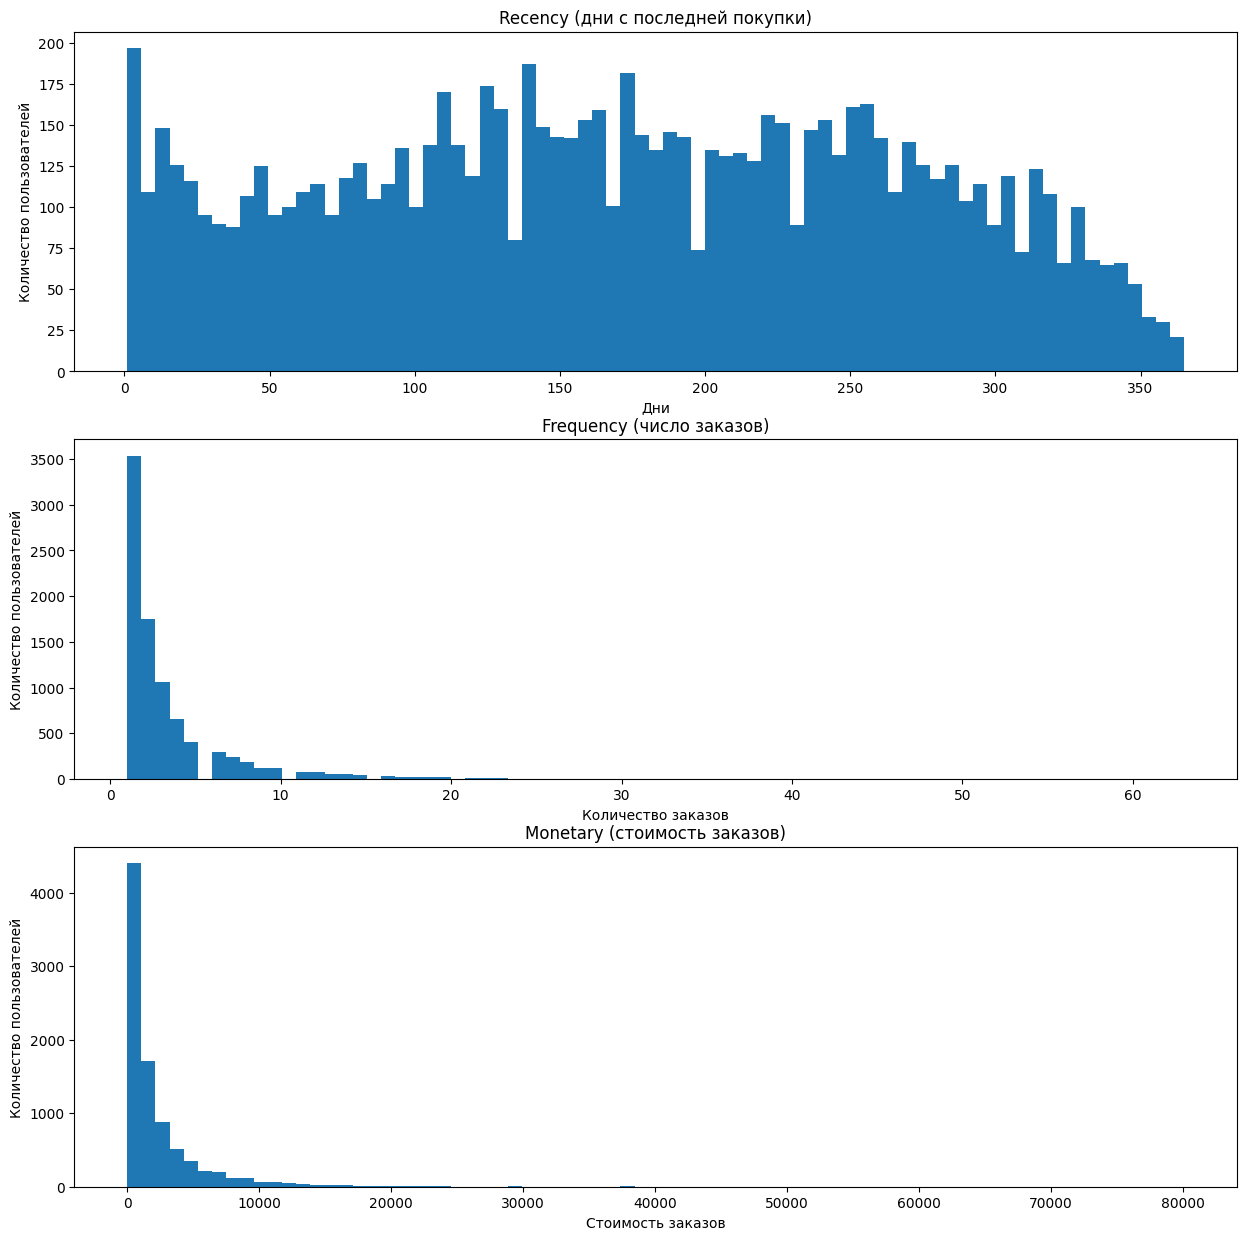

In [23]:
# Строим три гистограммы для RFM
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

# Recency
axes[0].hist(rfm['recency'], bins=75)
axes[0].set_title('Recency (дни с последней покупки)')
axes[0].set_xlabel('Дни')
axes[0].set_ylabel('Количество пользователей')

# Frequency
axes[1].hist(rfm['frequency'], bins=75)
axes[1].set_title('Frequency (число заказов)')
axes[1].set_xlabel('Количество заказов')
axes[1].set_ylabel('Количество пользователей')

# Monetary
axes[2].hist(rfm['monetary_value'], bins=75)
axes[2].set_title('Monetary (стоимость заказов)')
axes[2].set_xlabel('Стоимость заказов')
axes[2].set_ylabel('Количество пользователей')

plt.show()

По гистограммам видно, что давность заказов распределена равномерно, встречаются как новые, так и давно неактивные клиенты. Большинство сделали один заказ с небольшой суммой, а редкие крупные покупки формируют «хвост» распределения. Основная выручка приходится на небольшую группу лояльных клиентов с высокой частотой и большими чеками.

In [24]:
# Сегментируем по R, F, M
rfm['r'] = pd.cut(rfm['recency'], bins=3, labels=[3, 2, 1])
rfm['f'] = pd.cut(rfm['frequency'], bins=3, labels=[1, 2, 3])
rfm['m'] = pd.qcut(rfm['monetary_value'], q=3, labels=[1, 2, 3])

# Формируем RFM-группу
rfm['rfm_group'] = rfm['r'].astype(str) + rfm['f'].astype(str) + rfm['m'].astype(str)

# Считаем количество пользователей в каждом сегменте
rfm_group = rfm.groupby('rfm_group')['user_id'].nunique().reset_index()

# Сортируем по размеру сегмента
rfm_group.sort_values('user_id', ascending=False, inplace=True)

# Выодим результат
rfm_group

,rfm_group,user_id
6,213,1203
5,212,1151
4,211,1111
10,313,1033
9,312,965
8,311,937
0,111,927
1,112,857
2,113,659
11,323,42


Основная масса клиентов сосредоточена в сегментах 213, 212 и 211 — это покупатели с давними заказами, низкой суммой и редкой частотой. Следом идут группы 313, 312 и 311, где заказы были относительно недавно, но без высоких чеков. Сегменты 111, 112 и 113 представляют давно неактивных клиентов с минимальной ценностью. Самые небольшие, но стратегически важные группы — 323, 223, 123 и 333: это недавние и частые покупатели с высокой суммой заказов. Они формируют ядро лояльных клиентов. Основная точка роста — работа с массовыми сегментами средней ценности, чтобы переводить их в более прибыльные.  
Чтобы перейти от общей картины рапсределений и более детально сегментировать пользователей по их поведению, проведем кластеризацию методом k-means:

In [25]:
# Создаем сводную таблицу по пользователям
user_orders = df_orders.groupby('user_id').agg(
    orders_count=('order_id', 'nunique'),
    avg_price=('total_price', 'mean'),
    products_count=('product_name', 'nunique')
).reset_index()

user_orders.head()

,user_id,orders_count,avg_price,products_count
0,3,7,12455.890000,5
1,5,14,10098.557143,13
2,6,2,3695.760000,2
3,8,7,6485.910000,5
4,12,2,3020.060000,1


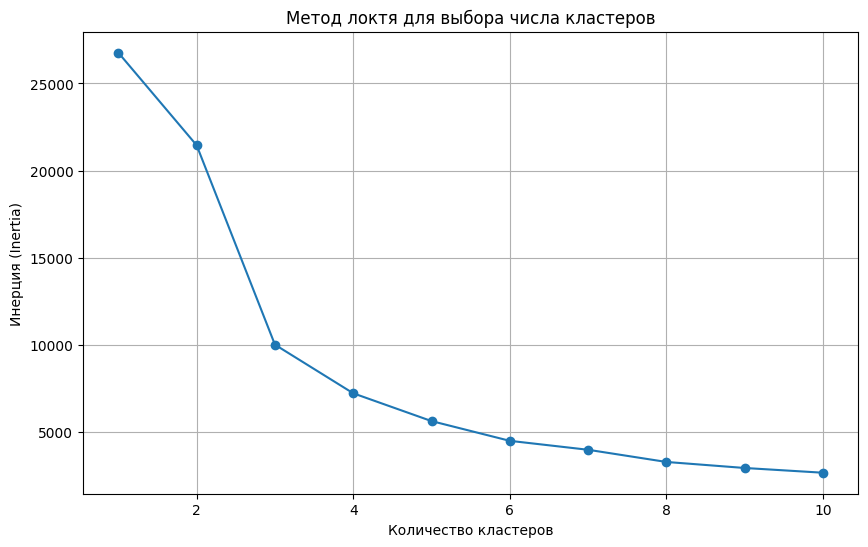

In [26]:
# Нормализуем данные 
scaler = StandardScaler()
X = user_orders[['orders_count', 'avg_price', 'products_count']]
X_scaled = scaler.fit_transform(X)

# Ищем оптимальное число кластеров методом "локтя"
inertia = []
possible_k = range(1, 11)

for k in possible_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(possible_k, inertia, marker='o')
plt.xlabel('Количество кластеров')
plt.ylabel('Инерция (Inertia)')
plt.title('Метод локтя для выбора числа кластеров')
plt.grid()
plt.show()

Линия графика «складывается» в точке 4. Следовательно, оптимальное число кластеров 4.

Центроиды кластеров (в исходном масштабе):


,Количество заказов,Средний чек,Количество товаров
Кластер 1,1.7,9427.9,1.6
Кластер 2,6.2,12503.3,5.6
Кластер 3,17.0,14325.1,13.0
Кластер 4,2.0,48111.9,1.9


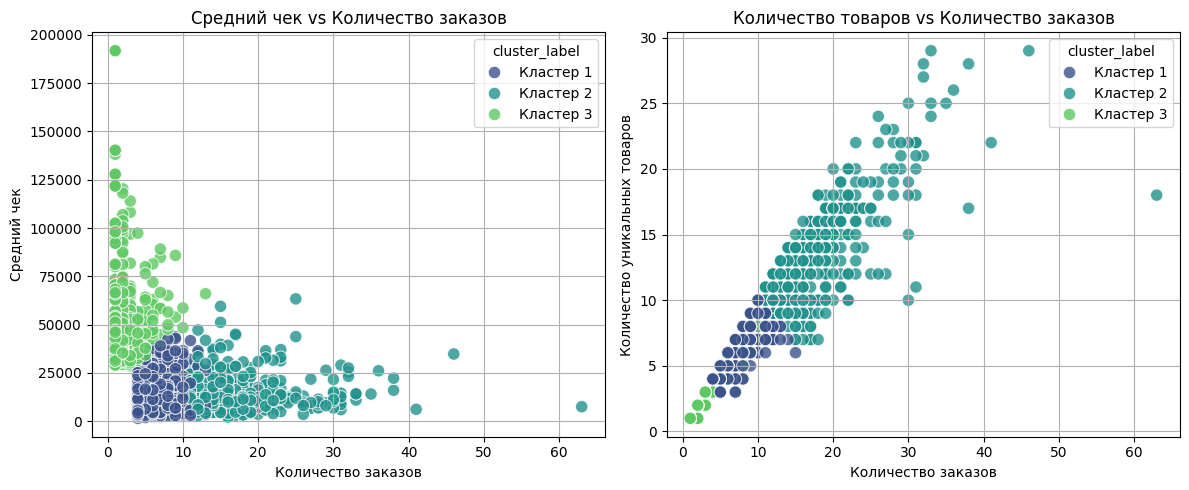

In [27]:
# Применяем K-means с 4 кластерами
kmeans = KMeans(n_clusters=4, random_state=1)
labels = kmeans.fit_predict(X_scaled)

# Сортируем кластеры по среднему чеку
sorted_indices = np.argsort(kmeans.cluster_centers_[:, 1])
sorted_centroids = kmeans.cluster_centers_[sorted_indices]

# Центроиды в исходном масштабе
centroids_original_scale = scaler.inverse_transform(sorted_centroids)
centroids_df = pd.DataFrame(
    centroids_original_scale,
    columns=['Количество заказов', 'Средний чек', 'Количество товаров'],
    index=[f'Кластер {i+1}' for i in range(kmeans.n_clusters)]
)
pd.options.display.float_format = '{:.1f}'.format
print('Центроиды кластеров (в исходном масштабе):')
display(centroids_df)

# Добавляем метки кластеров в исходные данные
user_orders['cluster_label'] = labels + 1
user_orders['cluster_label'] = user_orders['cluster_label'].map(dict(zip(
    [1, 2, 3],
    ['Кластер 1', 'Кластер 2', 'Кластер 3']
)))

# Строим график
plt.figure(figsize=(12, 5))

# Средний чек vs Количество заказов
plt.subplot(1, 2, 1)
sns.scatterplot(data=user_orders, x='orders_count', y='avg_price', 
                hue='cluster_label', palette='viridis', s=80, alpha=0.8)
plt.title('Средний чек vs Количество заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Средний чек')
plt.grid()

# Количество товаров vs Количество заказов
plt.subplot(1, 2, 2)
sns.scatterplot(data=user_orders, x='orders_count', y='products_count', 
                hue='cluster_label', palette='viridis', s=80, alpha=0.8)
plt.title('Количество товаров vs Количество заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Количество уникальных товаров')
plt.grid()

plt.tight_layout()
plt.show()

- Кластер 1 — это редкие покупатели с низким средним чеком и узким ассортиментом, вероятно, новички или случайные пользователи маркетплейса.
- Кластер 2 представляет активных покупателей со средним чеком и ассортиментом, у которых есть потенциал для увеличения среднего чека и расширения ассортимента. 
- Кластер 3 — это VIP-клиенты: они делают много заказов, покупают широкий ассортимент товаров и дают основную ценность маркетплейсу.
- Кластер 4 состоит из редких покупателей с очень крупными чеками, вероятно, покупающих премиальные товары, для которых важны персонализированные предложения и стимулирование повторных заказов.

Основная выручка приходит от VIP-клиентов, но есть заметный потенциал роста среди новичков и покупателей с редкими, но крупными заказами, поэтому стратегия маркетплейса должна одновременно удерживать VIP и стимулировать новые и редкие крупные покупки.

## Выводы по этапу 4

Анализ показал, что каналы привлечения работают по-разному. `Google Ads` изначально приносит прибыль, но к концу года эффективность падает. `Affiliate` и `Social Media` показывают стабильные результаты, `SEO` и `Email` работают слабее. `TikTok` оказался убыточным: CAC высокий, LTV низкий, а доля трафика выросла до 75%, что снизило общую рентабельность. По вовлечённости (stickiness) лидируют `SEO` и `Email Marketing`, а `TikTok` и `Social Media` — отстают.  
RFM-анализ показывает, что основную выручку приносят небольшие группы постоянных клиентов с частыми и крупными заказами. Массовые клиенты со средними показателями представляют основной потенциал для роста.  
Кластеризация выделила четыре группы пользователей: новички с низкими чеками, перспективные клиенты со средними показателями, VIP-клиенты — основа выручки, и редкие крупные покупатели премиум-товаров. Задача маркетплейса — удерживать VIP и стимулировать рост остальных сегментов с помощью разных стратегий.

Гипотезы для развития продукта:
1. Если предложить новичкам (кластер 1) персонализированные скидки или наборы популярных товаров, то частота их заказов увеличится. Основано на низкой текущей частоте и среднем чеке.
2. Если клиентам с давними, но редкими крупными покупками отправлять персонализированные предложения премиальных товаров, они начнут чаще повторять покупки. Основание: высокие чеки при низкой частоте — есть потенциал для повторных заказов при правильной мотивации.
3. Если увеличить персонализированные кампании в `Google Ads` и `Email Marketing`, то конверсия новых пользователей вырастет, опираясь на их стабильную эффективность и высокую конверсию.
4. Если перераспределить бюджет `TikTok` на `SEO` и `Affiliate`, то ROI маркетплейса повысится, так как эти каналы показывают высокую лояльность и конверсию, а `TikTok` привлекает трафик с низкой платежеспособностью.

## A/B-тестирование и валидация гипотез
Команда продукта рассмотрела предложенные гипотезы и приняла решение о воздействии на конверсию с помощью финансовых стимулов. В связи с безотлагательной ситуацией со снижением выручки, параллельно с продолжением анализа данных, к подготовке дизайн-документа был подключен другой аналитик. Проведение эксперимента поручено мне. При формировании выводов необходимо дополнить отчет рекомендациями по итогам теста и, при наличии, указать на проблемы, выявленные в ходе эксперимента.

<font size='3'><b>Дизайн эксперимента: Бонус на первую покупку для пользователей TikTok</b></font> 

В эксперименте участвовали новые пользователи, привлеченные через канал `TikTok`, которые зарегистрировались в период с 1 по 21 января 2025 года. Пользователей случайным образом разделили на две равные группы:
- Контрольная группа проходила стандартный путь покупки без дополнительных бонусов.
- Тестовая группа получала специальный бонус на первую покупку сразу после регистрации.

После разделения активность пользователей анализировали в течение трех недель.

Цель эксперимента — оценить, как финансовый стимул влияет на конверсию в первую покупку и общую выручку среди пользователей `TikTok`.

Чтобы увидеть полную картину, недостаточно следить только за конверсией. Команда выбрала для эксперимента такой набор метрик:
- Ключевая метрика — конверсия в первую покупку среди пользователей `TikTok`.
- Барьерная метрика — общая выручка с пользователей `TikTok`.
- Вспомогательная метрика 1 — ARPU (средняя выручка на пользователя `TikTok`).
- Вспомогательная метрика 2 — ARPPU (средняя выручка на покупателя `TikTok`).
- Вспомогательная метрика 3 — AOV (средний чек `TikTok`)

Ожидалось, что ключевая метрика покажет значительный рост, а барьерные метрики останутся на прежнем уровне или улучшатся.

### Предобработка данных

In [28]:
# Выгружаем датафреймы в переменные
events_abt = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_events_AB.csv',
                        parse_dates=['event_date', 'event_week', 'event_month'])

orders_abt = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_orders_AB.csv',
                        parse_dates=['order_date', 'order_week', 'order_month'])

sessions_abt = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_sessions_AB.csv',
                          parse_dates=['session_start', 'session_week', 'session_month'])

users_abt = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_users_AB.csv',
                       parse_dates=['registration_date', 'cohort_week', 'cohort_month'])

split_users_abt = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_AB_split_users.csv')

In [29]:
# Создаем список с датафреймами
df_list_abt = [events_abt, orders_abt, users_abt, split_users_abt]

# Выводим информацию о каждом датафрейме
for df in df_list_abt:
    print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831231 entries, 0 to 831230
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      831231 non-null  int64         
 1   session_id    831231 non-null  int64         
 2   user_id       831231 non-null  int64         
 3   event_date    831231 non-null  datetime64[ns]
 4   event_type    831231 non-null  object        
 5   os            831231 non-null  object        
 6   device        831231 non-null  object        
 7   event_index   831231 non-null  int64         
 8   user_segment  831231 non-null  object        
 9   product_name  409054 non-null  object        
 10  event_week    831231 non-null  datetime64[ns]
 11  event_month   831231 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(4), object(5)
memory usage: 76.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33280 entries, 0 to 33279
Data columns (total 10 c

Пропуски в `events_abt` согласуются с бизнес-логикой. Проверим, есть ли дубликаты:

In [30]:
df_names_abt = ['events_abt', 'orders_abt', 'users_abt', 'split_users_abt']

for df, name in zip(df_list_abt, df_names):
    full_duplicates = df[df.duplicated(keep=False)]
    print(f'Найдено полных дубликатов в {name}: {len(full_duplicates)} записей')

Найдено полных дубликатов в df_orders: 0 записей
Найдено полных дубликатов в df_campaign_costs: 0 записей
Найдено полных дубликатов в df_users: 0 записей
Найдено полных дубликатов в df_events: 0 записей


Явных дубликатов не обнаружено. Посмотрим, есть ли неявные дубликаты в `orders_abt`, одна товарная позиция в конкретном заказе пользователя должна быть уникальной:

In [31]:
# Создаем копию для анализа дубликатов
implicit_duplicates = orders_abt[orders_abt.duplicated(subset=['user_id','order_date', 'product_name','total_price'], keep=False)].copy()

# Выводим информацию о дубликатах
print(f"Найдено неявных дубликатов в orders_abt: {len(implicit_duplicates)} записей")

# Ставим условие для уведомления
if len(implicit_duplicates) > 0:
    orders_abt = orders_abt.drop_duplicates(subset=['user_id','order_date', 'product_name','total_price'], keep='first')
    print('Дубликаты удалены')

# Создаем новую копию без дубликатов
df_orders_clean = orders_abt.drop_duplicates(subset=['user_id','order_date', 'product_name','total_price'], keep='first').copy()

# Продолжаем работать с очищенной версией
orders_abt = df_orders_clean

Найдено неявных дубликатов в orders_abt: 555 записей
Дубликаты удалены


Выборки должны быть независимы. Убедимся, что в тестовой и контрольной группах не встречаются одни и те же пользователи:

In [32]:
# Считаем количество групп на пользователя
user_group_count = split_users_abt.groupby('user_id')['group'].nunique()

# Выводим результат
if (user_group_count > 1).any():
    print('Группы зависимы')
else:
    print('Группы независимы')

Группы независимы


В данных должны быть только те пользователи, которые участвовали в эксперименте. Отфильтруем датафреймы по `split_users_abt`:

In [33]:
# Оставляем только тех, кто участвовал в эксперименте
users_abt = users_abt.merge(split_users_abt, on='user_id')
events_abt = events_abt[events_abt['user_id'].isin(users_abt['user_id'])]
orders_abt = orders_abt[orders_abt['user_id'].isin(users_abt['user_id'])]

Группы также должны иметь схожий размер:

In [34]:
# Разделяем на группы
test = users_abt[users_abt['group'] == 'treatment']
control = users_abt[users_abt['group'] == 'control']

# Считаем уникальных пользователей по группам
test_a = control['user_id'].nunique()
test_b = test['user_id'].nunique()

# Находим процентную разницу в количестве пользователей
p = abs(test_a - test_b) / test_a * 100

# Выводим результат
print(f'Количество пользователей в группе А: {test_a}\n'
      f'Количество пользователей в группе B: {test_b}\n'
      f'P = {p}')

Количество пользователей в группе А: 1503
Количество пользователей в группе B: 1465
P = 2.5282767797737855


Присутствует небольшой 3% перекос в сторону контрольной группы, что не явлется критичным. Более важно соблюдать сопоставимость наблюдаемых групп. Посмотрим на распределния категорильных признаков:

<Figure size 1000x700 with 0 Axes>

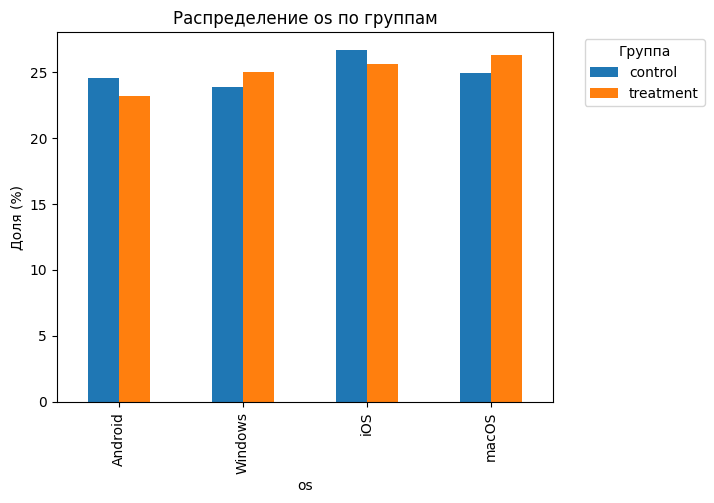

<Figure size 1000x700 with 0 Axes>

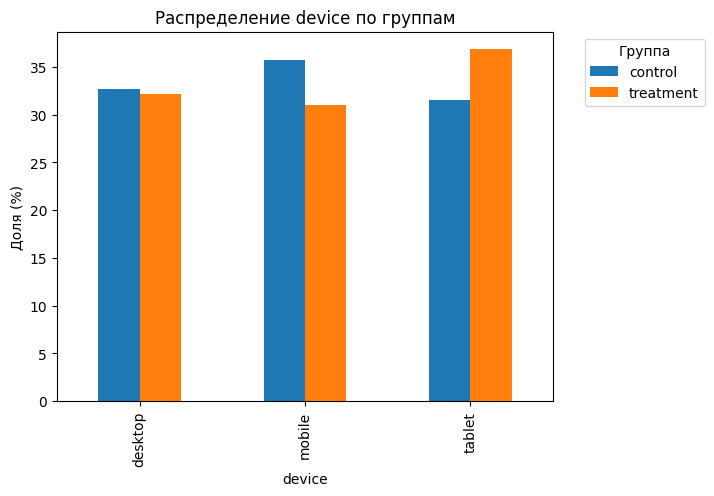

<Figure size 1000x700 with 0 Axes>

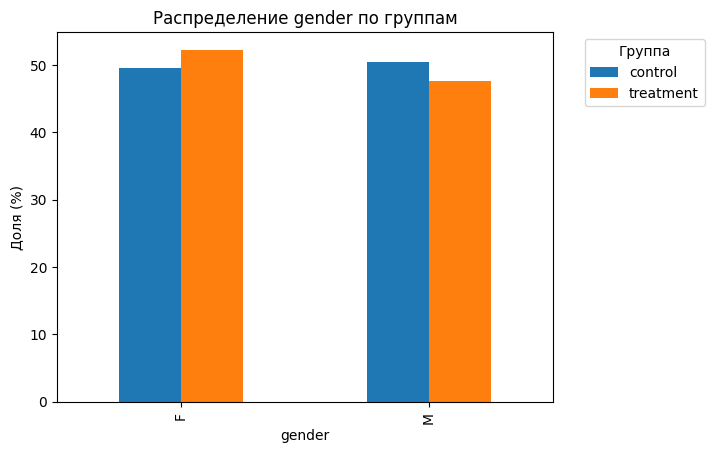

In [35]:
# Создаем фунцию для построения распределния категориальных признаков
def plot_categorical_distribution(df, feature, group_col='group'):
    # Создаем таблицу сопряженности с долями внутри групп
    dist = pd.crosstab(df[feature], df[group_col], normalize='columns') * 100
    
    # Cтроим график
    plt.figure(figsize=(10,7))
    
    dist.plot(kind='bar')
    
    plt.title(f'Распределение {feature} по группам')
    plt.ylabel('Доля (%)')
    plt.xlabel(feature)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Группа')
    plt.show()

# Применяем функцию
plot_categorical_distribution(users_abt, 'os')
plot_categorical_distribution(users_abt, 'device')
plot_categorical_distribution(users_abt, 'gender')

Наблюдается небольшой дисбаланс, который, вероятно, связан с шумом. Теперь рассмотрим распределние по возрастам:

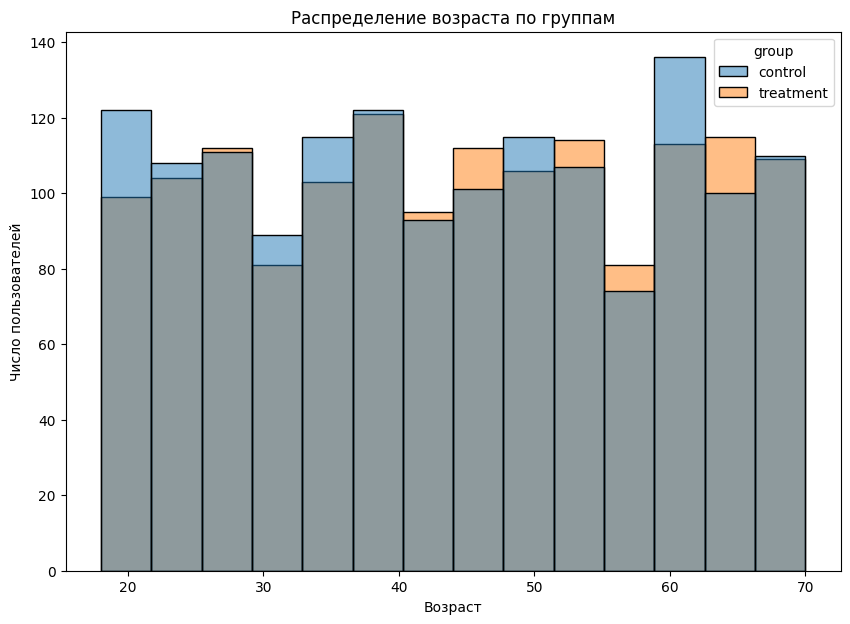

In [36]:
#Строим график
plt.figure(figsize=(10,7))

sns.histplot(
    data=users_abt,
    x='age',
    hue='group')

plt.title('Распределение возраста по группам')
plt.xlabel('Возраст')
plt.ylabel('Число пользователей')
plt.show()

Распределения по возрастам тоже близки.  
Группы независимы и сопоставимы. 

### Исследование результатов эксперимента
Посмотрим, как изменилось поведение пользователей после финансовой стимуляции:

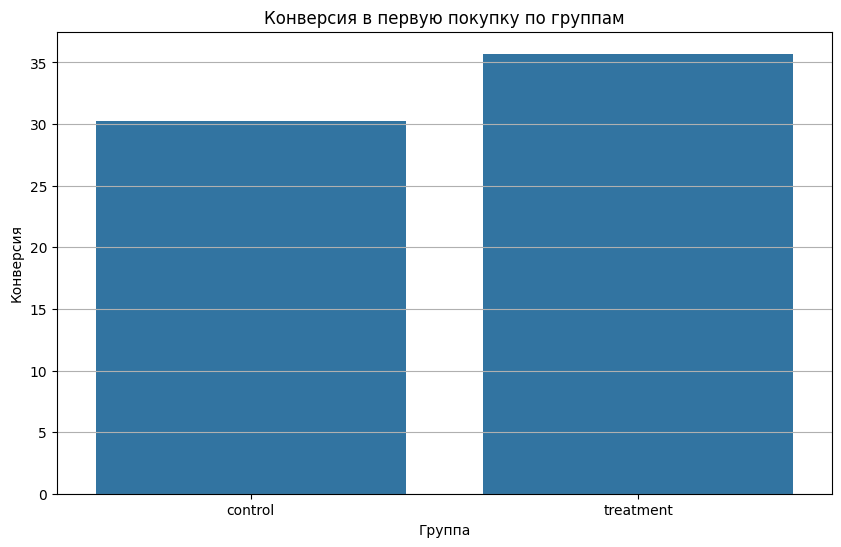

In [37]:
# Объединяем данные
events_with_group = events_abt.merge(users_abt[['user_id', 'group']], on='user_id')

# Фильтруем и считаем покупателей по группам
buyers_groups = events_with_group[events_with_group['event_type'] == 'checkout_complete']

buyers_groups = (buyers_groups.groupby('group')['user_id']
                 .nunique()
                 .reset_index()
                 .rename(columns={'user_id': 'buyers_count'}))

# Считаем пользователей по группам
users_groups = (events_with_group.groupby('group')['user_id']
                .nunique()
                .reset_index()
                .rename(columns={'user_id': 'users_count'}))

# Объединяем и считаем конверсию в заказ
conversion = pd.merge(buyers_groups,
                     users_groups,
                     on='group')

conversion['CR'] = round(100 * conversion['buyers_count'] / conversion['users_count'], 2)

# Строим график
plt.figure(figsize=(10, 6))

sns.barplot(data=conversion,
        x='group',
        y='CR')

plt.title('Конверсия в первую покупку по группам')
plt.xlabel('Группа')
plt.ylabel('Конверсия')
plt.grid(axis='y')

Конверсия в заказ увеличилась примерно на 5%, доля платящих пользователей с канала `TikTok` действительно увеличилась. Посмотрим, как имзенились другие метрики:

In [38]:
# Объединяем все данные
orders_with_group = orders_abt.merge(users_abt[['user_id', 'group']], on='user_id')

# Используем предыдущие рассчеты 
key_metric = conversion.set_index('group')['CR']

# Cчитаем барьерную метрику
orders_with_group['revenue'] = orders_with_group['total_price'] * 0.05
barrier_metric = (orders_with_group.groupby('group')['revenue']
                  .sum())

# Считаем вспомогательную метрику 1
total_users = users_abt.groupby('group')['user_id'].nunique()
arpu_metric = barrier_metric / total_users

# Считаем вспомогательную метрику 2
paying_users = orders_with_group.groupby('group')['user_id'].nunique()
arppu_metric = barrier_metric / paying_users

# Считаем вспомогательную метрику 3
total_orders = orders_with_group.groupby('group')['order_id'].nunique()
aov_metric = barrier_metric / total_orders

# Создаем функцию для подсчета изменений
def calculate_changes(metric):
    abs_change = metric.loc['treatment'] - metric.loc['control']
    rel_change = (abs_change / metric.loc['control']) * 100

    return abs_change, rel_change

key_abs, key_rel = calculate_changes(key_metric)
barrier_abs, barrier_rel = calculate_changes(barrier_metric)
arpu_abs, arpu_rel = calculate_changes(arpu_metric)
arppu_abs, arppu_rel = calculate_changes(arppu_metric)
aov_abs, aov_rel = calculate_changes(aov_metric)

# Создаем сводную таблицу
results = pd.DataFrame({
    'Metric': [
        'Конверсия в первую покупку (checkout_complete)',
        'Общая выручка',
        'ARPU (средняя выручка на пользователя)',
        'ARPPU (средняя выручка на покупателя)',
        'AOV (средний чек)'
    ],
    'Control': [
        f"{key_metric.loc['control']:.2f}%",
        f"{barrier_metric.loc['control']:.2f}",
        f"{arpu_metric.loc['control']:.2f}",
        f"{arppu_metric.loc['control']:.2f}",
        f"{aov_metric.loc['control']:.2f}"
    ],
    'Treatment': [
        f"{key_metric.loc['treatment']:.2f}%",
        f"{barrier_metric.loc['treatment']:.2f}",
        f"{arpu_metric.loc['treatment']:.2f}",
        f"{arppu_metric.loc['treatment']:.2f}",
        f"{aov_metric.loc['treatment']:.2f}"
    ],
    'Absolute Change': [
        f"{key_abs:.2f}%",
        f"{barrier_abs:.2f}",
        f"{arpu_abs:.2f}",
        f"{arppu_abs:.2f}",
        f"{aov_abs:.2f}"
    ],
    'Relative Change': [
        f"{key_rel:.2f}%",
        f"{barrier_rel:.2f}%",
        f"{arpu_rel:.2f}%",
        f"{arppu_rel:.2f}%",
        f"{aov_rel:.2f}%"
    ]
})

# Выводим результат
print(results)

                                           Metric   Control  Treatment  \
0  Конверсия в первую покупку (checkout_complete)    30.27%     35.71%   
1                                   Общая выручка  18918.65  191866.42   
2          ARPU (средняя выручка на пользователя)     12.59     130.97   
3           ARPPU (средняя выручка на покупателя)   1182.42    1744.24   
4                               AOV (средний чек)    788.28     837.84   

  Absolute Change Relative Change  
0           5.44%          17.97%  
1       172947.78         914.17%  
2          118.38         940.47%  
3          561.82          47.52%  
4           49.57           6.29%  


Эксперимент дал заметное улучшение почти по всем ключевым метрикам. Конверсия в первую покупку у `treatment ` увеличилась на 18% относительно контрольной группы.  
По выручке разрыв ещё более значительный с приростом свыше девяти раз, что повлекло за собой сильный скачок ARPU — с 12,59 до 130,97, то есть почти в десять раз. Это говорит о том, что пользователи `treatment` приносили гораздо больше денег в среднем, даже если учитывать всех пользователей, а не только платящих.  
ARPPU также увеличился: с 1182 до 1744, прирост около 47%. Здесь рост умереннее, чем у ARPU, что логично — метрика считается только на платящих, и при большом росте конверсии разница немного сглаживается.  
Средний чек (AOV) вырос на 6%. Этот эффект выглядит небольшим, но в совокупности с ростом конверсии и числа покупателей он тоже внес вклад в рост выручки.  
В целом результаты показывают, что `treatment` сильно превзошла контрольную как по конверсии, так и по монетизационным метрикам. Наибольший эффект виден в ARPU и общей выручке, что связано с увеличением количества пользователей, совершающих покупки.  
Проверим являются ли эти изменения статистически значимыми. Сформулируем гипотезы:
1. Для конверсии в первую покупку (Z-тест пропорций)
**H0**: Доля пользователей, совершивших первую покупку, в тестовой группе не превышает долю в контрольной группе.
p_test ≤ p_control  
**H1**: Доля пользователей, совершивших первую покупку, в тестовой группе превышает долю в контрольной группе.
p_test > p_control  

2. Для общей выручки (T-тест)
**H0**: Общая выручка с пользователей в тестовой группе не превышает выручку в контрольной группе.
mu_test_revenue ≤ mu_control_revenue  
**H1**: Общая выручка с пользователей в тестовой группе превышает выручку в контрольной группе.
mu_test_revenue > mu_control_revenue  

3. Для ARPU - средней выручки на пользователя (T-тест)
**H0**: Средняя выручка на одного пользователя в тестовой группе не превышает контрольную группу.
mu_test_arpu ≤ mu_control_arpu  
**H1**: Средняя выручка на одного пользователя в тестовой группе превышает контрольную группу.
mu_test_arpu > mu_control_arpu  

4. Для ARPPU - средней выручки на покупателя (T-тест)
**H0**: Средняя выручка на одного покупателя в тестовой группе не превышает контрольную группу.
mu_test_arppu ≤ mu_control_arppu  
**H1**: Средняя выручка на одного покупателя в тестовой группе превышает контрольную группу.
mu_test_arppu > mu_control_arppu  

5. Для AOV - среднего чека (T-тест)
**H0**: Средний чек в тестовой группе не превышает контрольную группу.
mu_test_aov ≤ mu_control_aov  
**H1**: Средний чек в тестовой группе превышает контрольную группу.
mu_test_aov > mu_control_aov  

In [39]:
# Для конверсии в первую покупку (Z-тест пропорций)
m_control = conversion.loc[0, 'buyers_count']
n_control = conversion.loc[0, 'users_count']

m_test = conversion.loc[1, 'buyers_count']
n_test = conversion.loc[1, 'users_count']

stat, p_value_conv = proportions_ztest(
    [m_test, m_control],
    [n_test, n_control],
    alternative='larger'
)

print(f'1. Конверсия в первую покупку: {"Изменение статистически значимо" if p_value_conv < 0.05 else "Изменение статистически не значимо"}')
print()

# Для общей выручки (T-тест)
control_revenue = orders_with_group[orders_with_group['group'] == 'control']['revenue']
test_revenue = orders_with_group[orders_with_group['group'] == 'treatment']['revenue']

_, p_value_rev = ttest_ind(test_revenue, control_revenue, equal_var=False, alternative='greater')

print(f'2. Общая выручка: {"Изменение статистически значимо" if p_value_rev < 0.05 else "Изменение статистически не значимо"}')
print()

# Для ARPU - средней выручки на пользователя (T-тест)
# Создаем данные для ARPU
control_arpu = []
test_arpu = []

for user_id in users_abt[users_abt['group'] == 'control']['user_id']:
    user_revenue = orders_with_group[orders_with_group['user_id'] == user_id]['revenue'].sum()
    control_arpu.append(user_revenue)

for user_id in users_abt[users_abt['group'] == 'treatment']['user_id']:
    user_revenue = orders_with_group[orders_with_group['user_id'] == user_id]['revenue'].sum()
    test_arpu.append(user_revenue)

_, p_value_arpu = ttest_ind(test_arpu, control_arpu, equal_var=False, alternative='greater')

print(f'3. ARPU (выручка на пользователя): {"Изменение статистически значимо" if p_value_arpu < 0.05 else "Изменение статистически не значимо"}')
print()

# Для ARPPU - средней выручки на покупателя (T-тест)
control_paying_users = orders_with_group[orders_with_group['group'] == 'control']['user_id'].unique()
test_paying_users = orders_with_group[orders_with_group['group'] == 'treatment']['user_id'].unique()

control_arppu = []
test_arppu = []

for user_id in control_paying_users:
    user_revenue = orders_with_group[orders_with_group['user_id'] == user_id]['revenue'].sum()
    control_arppu.append(user_revenue)

for user_id in test_paying_users:
    user_revenue = orders_with_group[orders_with_group['user_id'] == user_id]['revenue'].sum()
    test_arppu.append(user_revenue)

_, p_value_arppu = ttest_ind(test_arppu, control_arppu, equal_var=False, alternative='greater')

print(f'4. ARPPU (выручка на покупателя): {"Изменение статистически значимо" if p_value_arppu < 0.05 else "Изменение статистически не значимо"}')
print()

# Для AOV - среднего чека (T-тест)
control_orders = orders_with_group[orders_with_group['group'] == 'control']['revenue']
test_orders = orders_with_group[orders_with_group['group'] == 'treatment']['revenue']

_, p_value_aov = ttest_ind(test_orders, control_orders, equal_var=False, alternative='greater')

print(f'5. AOV (средний чек): {"Изменение статистически значимо" if p_value_aov < 0.05 else "Изменение статистически не значимо"}')
print()

1. Конверсия в первую покупку: Изменение статистически не значимо

2. Общая выручка: Изменение статистически не значимо

3. ARPU (выручка на пользователя): Изменение статистически значимо

4. ARPPU (выручка на покупателя): Изменение статистически значимо

5. AOV (средний чек): Изменение статистически не значимо



Эксперимент показал рост средней выручки на пользователя и на покупателя, но конверсия, общая выручка и средний чек статистически не изменились. Пользователи стали тратить больше, но общий доход и количество заказов остались примерно на том же уровне.

## Выводы по этапу 5

Бонус на первую покупку для пользователей `TikTok` привёл к росту средней выручки на пользователя и на покупателя. Однако конверсия и общая выручка статистически не изменились. Фича оказала локальный эффект на поведение отдельных пользователей, но не дала улучшения целевой метрики. При этом результаты могли быть частично смещены сезонными факторами января, поэтому для уверенного масштабирования на другие периоды стоит учитывать влияние сезонности и проводить дополнительный анализ или повторный эксперимент в другой период.